<a href="https://colab.research.google.com/github/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/blob/main/pronostico_revpar_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Pronóstico RevPAR - Versión PRO (Colab)
Notebook completo con validación, features avanzadas, modelos y exportación.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import (mean_absolute_percentage_error, r2_score,
                                     mean_absolute_error, mean_squared_error)
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils  import get_column_letter

In [ ]:
# ── Estilo global ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "figure.dpi":        130,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

AZUL      = "#1B3A5C"
AZUL_MED  = "#2E6DA4"
AZUL_CLARO= "#BDD7EE"
DORADO    = "#C9A84C"
ROJO      = "#C0392B"
VERDE     = "#27AE60"
GRIS      = "#8A8A8A"
TEMP_PAL  = {"Alta": "#C0392B", "Media": "#E67E22", "Baja": "#2E6DA4"}

In [ ]:
# ============================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ============================================================

# Para clonar un repositorio de GitHub
# Reemplaza 'TU_URL_DEL_REPOSITORIO' con la URL real de tu repositorio.
!git clone https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git

print("https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git")

fatal: destination path 'Trabajo-de-Grado_Hotel_Portoalegre' already exists and is not an empty directory.
https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git


In [ ]:
# Read df_temporalidad

github_raw_url_temp = 'https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_temporalidad.xlsx'

try:
    df = pd.read_excel(github_raw_url_temp)
    print(f"✔ Archivo cargado desde GitHub (nueva carga): {github_raw_url_temp} | Filas: {len(df)}")
    display(df.head())
except Exception as e:
    print(f"❌ Error al intentar leer el archivo desde GitHub: {e}")

✔ Archivo cargado desde GitHub (nueva carga): https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_temporalidad.xlsx | Filas: 1058


,fecha_noche,personas,ingresos,cuartos_ocupados,ingreso_por_huesped,ingreso_por_cuarto,ocupacion,precipitacion_mm,sol_horas,temporada,...,ocupacion_lag1,ocupacion_lag7,ingresos_lag1,ingresos_lag7,ocupacion_ma7,ingresos_ma7,dow_sin,dow_cos,mes_sin,mes_cos
0,2023-02-08,64,6.603937e+06,26,103186.513802,253997.572436,0.438356,0.0,11.195083,Baja,...,0.465753,0.301370,6.688893e+06,4.416740e+06,0.528376,7.493013e+06,0.974928,-0.222521,0.866025,0.5
1,2023-02-09,48,4.925649e+06,20,102617.681597,246282.435833,0.328767,0.0,11.192797,Baja,...,0.438356,0.369863,6.603937e+06,5.598111e+06,0.547945,7.805470e+06,0.433884,-0.900969,0.866025,0.5
2,2023-02-10,44,4.212566e+06,15,95740.135606,280837.731111,0.301370,0.0,11.257283,Baja,...,0.328767,0.636986,4.925649e+06,8.838389e+06,0.542074,7.709404e+06,-0.433884,-0.900969,0.866025,0.5
3,2023-02-11,39,4.132927e+06,16,105972.482295,258307.925595,0.267123,0.0,11.187792,Baja,...,0.301370,0.821918,4.212566e+06,1.134276e+07,0.494129,7.048572e+06,-0.974928,-0.222521,0.866025,0.5
4,2023-02-12,23,2.212260e+06,9,96185.223602,245806.682540,0.157534,0.2,11.251803,Baja,...,0.267123,0.458904,4.132927e+06,6.788844e+06,0.414873,6.018595e+06,-0.781831,0.623490,0.866025,0.5


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 1. CARGA Y CÁLCULO DE RevPAR
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  1. CARGA Y CÁLCULO DE RevPAR")
print("═"*62)

#df = pd.read_excel("df_temporalidad.xlsx")
df["fecha_noche"] = pd.to_datetime(df["fecha_noche"])
df = df.sort_values("fecha_noche").reset_index(drop=True)

# RevPAR = ADR × Ocupación  (Revenue per Available Room)
df["revpar"]  = df["ingreso_por_cuarto"] * df["ocupacion"]
df["adr"]     = df["ingreso_por_cuarto"]   # Average Daily Rate
df["semana"]  = df["fecha_noche"].dt.isocalendar().week.astype(int)
df["trimestre"] = df["fecha_noche"].dt.quarter

revpar_2024 = df[df["año"] == 2024]["revpar"].mean()
revpar_2025 = df[df["año"] == 2025]["revpar"].mean()
meta_revpar  = revpar_2024 * 1.05

print(f"  RevPAR promedio 2024 (baseline): {revpar_2024:>12,.0f} COP")
print(f"  RevPAR promedio 2025 (real):     {revpar_2025:>12,.0f} COP")
print(f"  Meta RevPAR (+5%):               {meta_revpar:>12,.0f} COP")
print(f"  Crec. 2024→2025 real:            {(revpar_2025/revpar_2024-1)*100:>11.1f} %")


══════════════════════════════════════════════════════════════
  1. CARGA Y CÁLCULO DE RevPAR
══════════════════════════════════════════════════════════════
  RevPAR promedio 2024 (baseline):      131,204 COP
  RevPAR promedio 2025 (real):          161,527 COP
  Meta RevPAR (+5%):                    137,765 COP
  Crec. 2024→2025 real:                   23.1 %


## Análisis Exploratorio — RevPAR Hotel

![Análisis Exploratorio — RevPAR Hotel](01_eda_revpar.png)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 2. EDA — RevPAR
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  2. EDA — RevPAR")
print("═"*62)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Análisis Exploratorio — RevPAR Hotel", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── 2a. Serie RevPAR completa ─────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
for yr, col in [(2023, AZUL_CLARO), (2024, AZUL_MED), (2025, AZUL)]:
    sub = df[df["año"] == yr]
    ax.plot(sub["fecha_noche"], sub["revpar"] / 1e3,
            color=col, linewidth=1.2 if yr < 2025 else 2, label=str(yr), alpha=0.9)

ax.fill_between(df["fecha_noche"], df["revpar"] / 1e3,
                alpha=0.06, color=AZUL_MED)
ax.axhline(revpar_2024 / 1e3, color=DORADO, linestyle="--", linewidth=1.5,
           label=f"Baseline 2024: {revpar_2024/1e3:,.0f}K")
ax.axhline(meta_revpar / 1e3, color=VERDE, linestyle="--", linewidth=1.5,
           label=f"Meta +5%: {meta_revpar/1e3:,.0f}K")
ax.set_title("Serie temporal RevPAR (COP miles)")
ax.set_ylabel("Miles COP")
ax.legend(fontsize=9, loc="upper left")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)

# ── 2b. RevPAR por temporada ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
temp_order = ["Baja", "Media", "Alta"]
data_box = [df[df["temporada"] == t]["revpar"].values / 1e3 for t in temp_order]
bp = ax.boxplot(data_box, patch_artist=True, labels=temp_order,
                medianprops={"color": "white", "linewidth": 2})
for patch, t in zip(bp["boxes"], temp_order):
    patch.set_facecolor(TEMP_PAL[t])
    patch.set_alpha(0.85)
ax.set_title("RevPAR por temporada (miles COP)")
ax.set_ylabel("Miles COP")

# ── 2c. RevPAR por día de semana ──────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
dow_lbl = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
occ_dow = df.groupby("dow")["revpar"].mean() / 1e3
colors_dow = [DORADO if i >= 5 else AZUL_MED for i in range(7)]
bars = ax.bar(dow_lbl, occ_dow.values, color=colors_dow, edgecolor="white")
ax.set_title("RevPAR promedio por día de semana")
ax.set_ylabel("Miles COP")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
            f"{b.get_height():.0f}K", ha="center", fontsize=8)

# ── 2d. RevPAR vs Ocupación (scatter) ────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for t in ["Baja", "Media", "Alta"]:
    sub = df[df["temporada"] == t]
    ax.scatter(sub["ocupacion"], sub["revpar"] / 1e3,
               color=TEMP_PAL[t], alpha=0.45, s=18, label=t, edgecolors="none")
z = np.polyfit(df["ocupacion"], df["revpar"] / 1e3, 1)
xline = np.linspace(df["ocupacion"].min(), df["ocupacion"].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), color=ROJO, linewidth=1.5, linestyle="--")
corr = df["ocupacion"].corr(df["revpar"])
ax.set_title(f"RevPAR vs. Ocupación (r={corr:.2f})")
ax.set_xlabel("Ocupación")
ax.set_ylabel("RevPAR (miles COP)")
ax.legend(fontsize=8)

# ── 2e. RevPAR vs ADR ─────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.scatter(df["adr"] / 1e3, df["revpar"] / 1e3,
           c=df["ocupacion"], cmap="Blues", alpha=0.5, s=18, edgecolors="none")
ax.set_title("RevPAR vs. ADR (color = ocupación)")
ax.set_xlabel("ADR (miles COP)")
ax.set_ylabel("RevPAR (miles COP)")
sm = plt.cm.ScalarMappable(cmap="Blues",
     norm=plt.Normalize(df["ocupacion"].min(), df["ocupacion"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Ocupación", shrink=0.8)

# ── 2f. Evolución mensual RevPAR por año ─────────────────────────
ax = fig.add_subplot(gs[2, 1:])
mes_lbl = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
for yr, col, lw in [(2023, AZUL_CLARO, 1.5), (2024, AZUL_MED, 2), (2025, AZUL, 2.5)]:
    sub = df[df["año"] == yr].groupby("mes")["revpar"].mean() / 1e3
    ax.plot(sub.index, sub.values, color=col, linewidth=lw,
            marker="o", markersize=5, label=str(yr))
ax.set_title("RevPAR mensual promedio por año")
ax.set_xlabel("Mes")
ax.set_ylabel("Miles COP")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mes_lbl)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
ax.axhline(meta_revpar / 1e3, color=VERDE, linestyle=":", linewidth=1.2,
           alpha=0.7, label="Meta")

plt.savefig("01_eda_revpar.png")
plt.close()
print("  ✓ 01_eda_revpar.png")



══════════════════════════════════════════════════════════════
  2. EDA — RevPAR
══════════════════════════════════════════════════════════════
  ✓ 01_eda_revpar.png


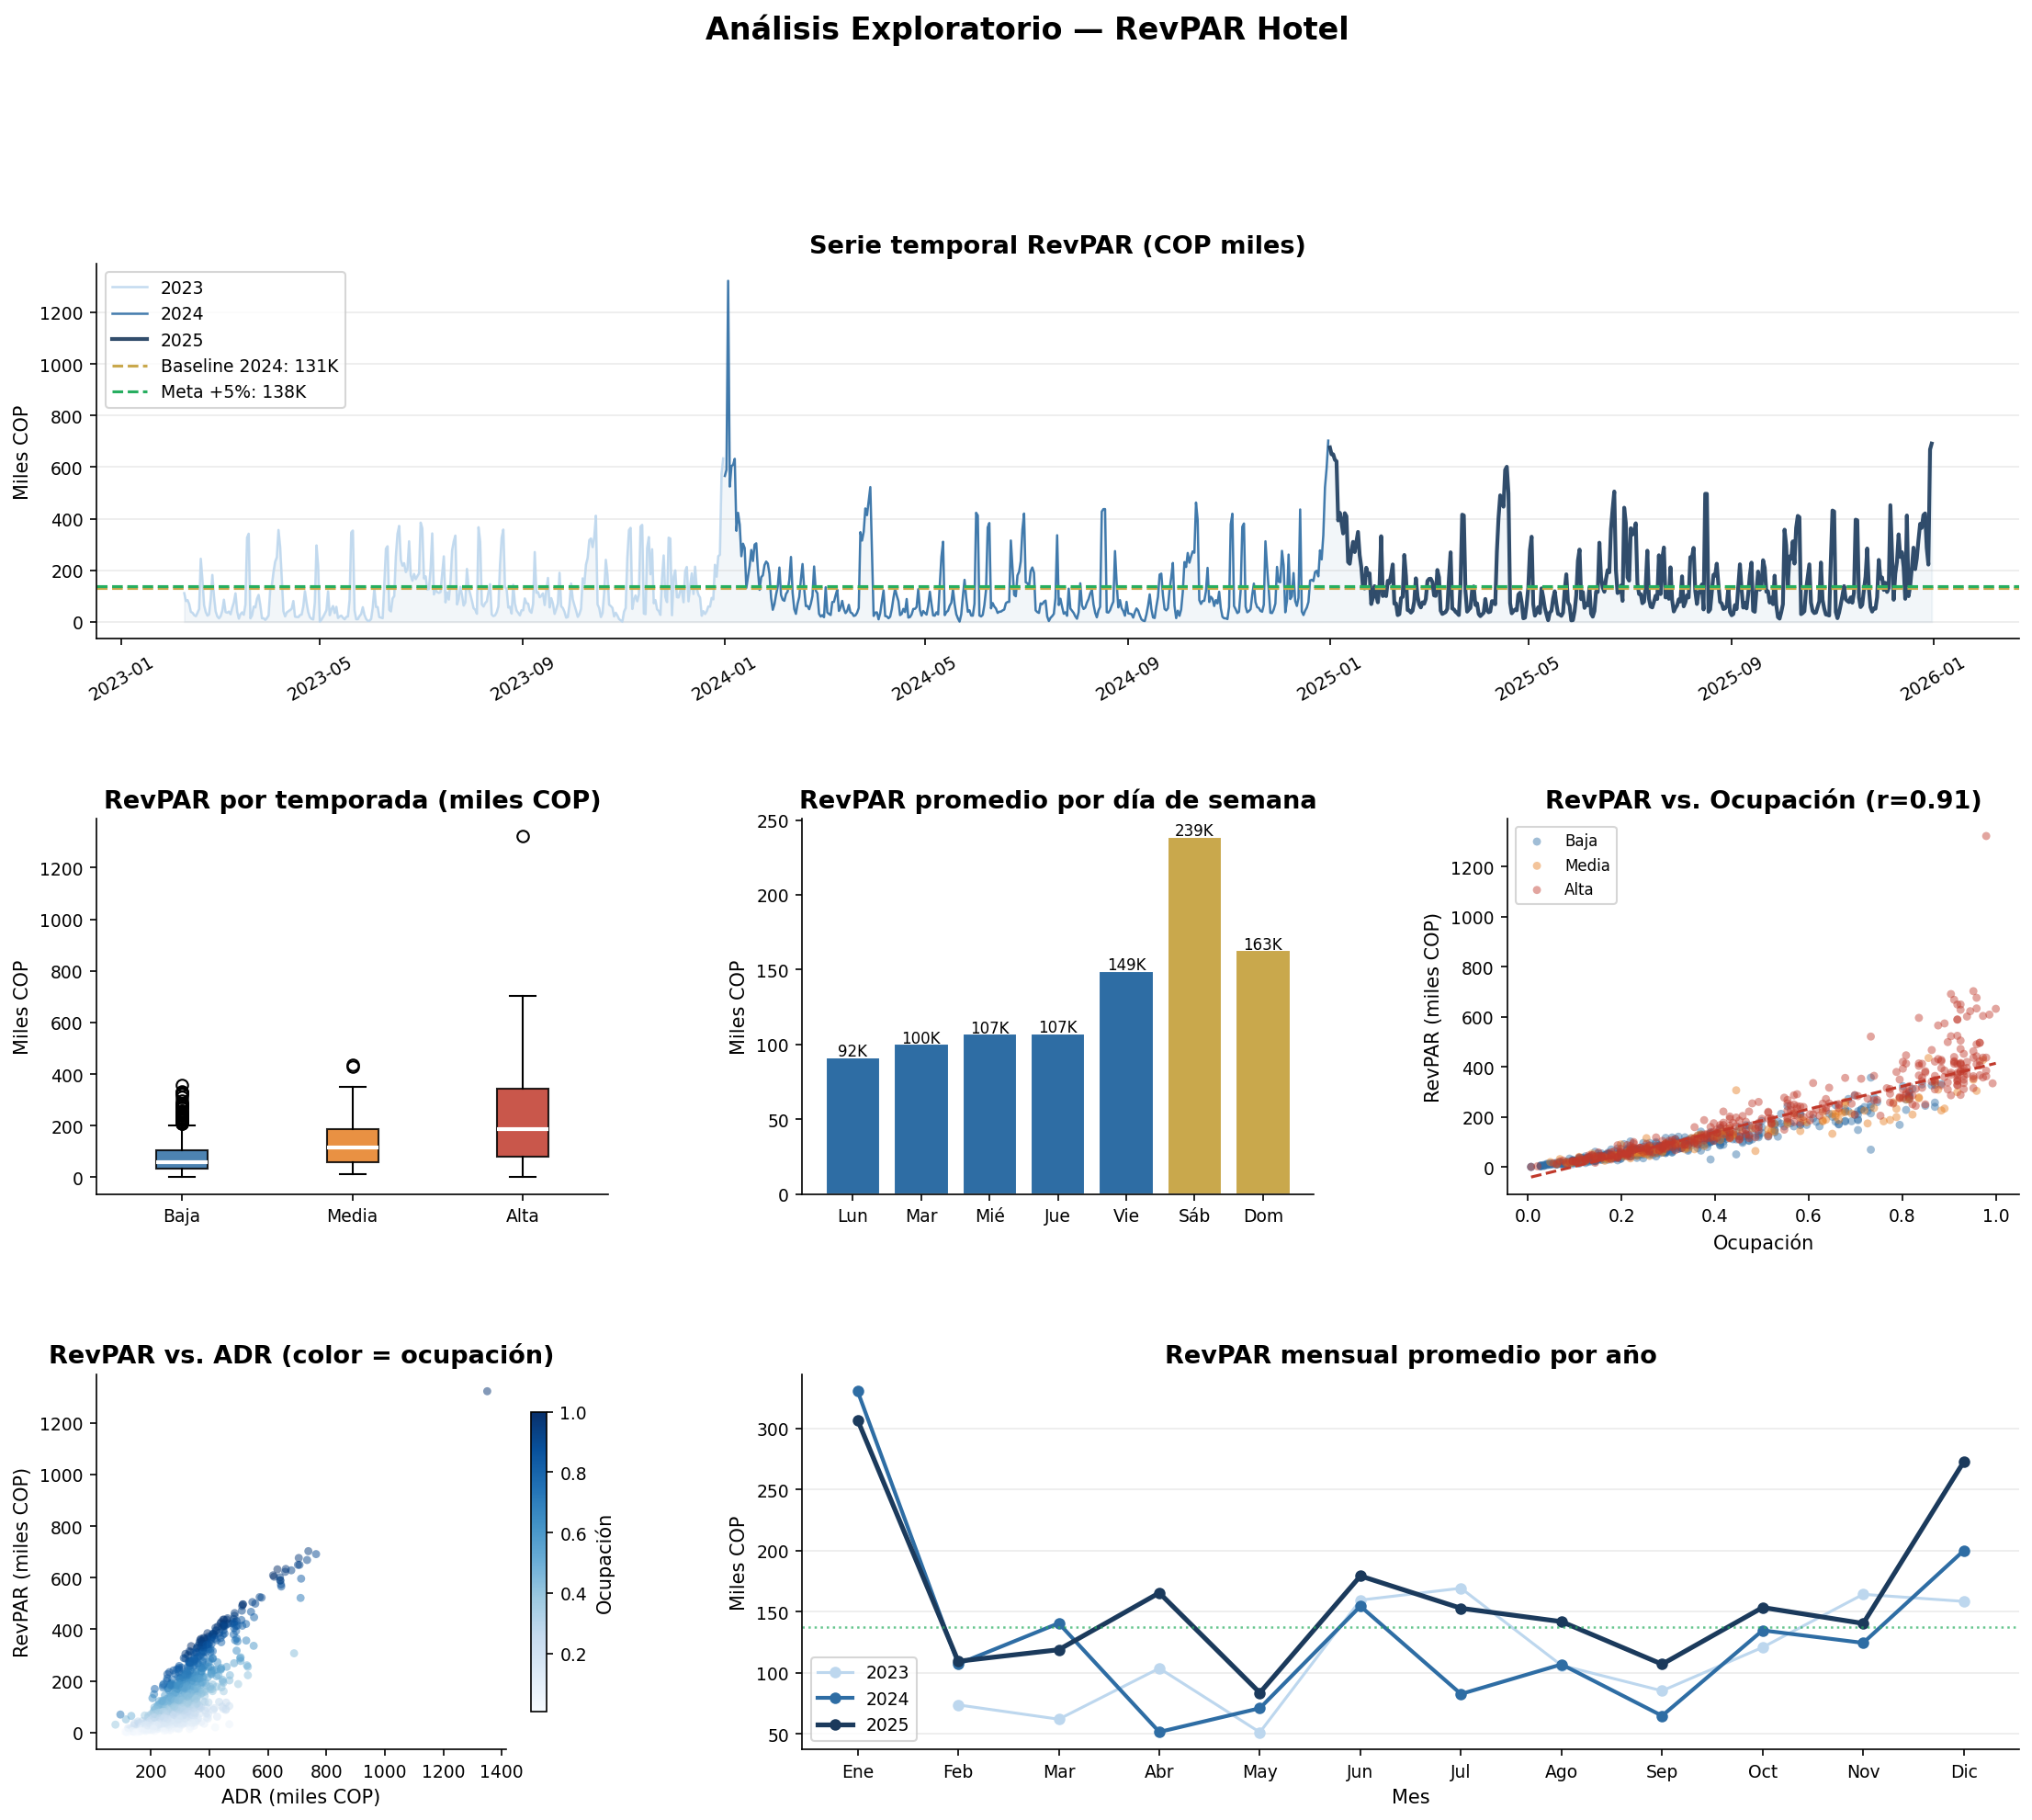

In [ ]:
from IPython.display import Image
Image('01_eda_revpar.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 3. ESTACIONALIDAD Y DESCOMPOSICIÓN
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  3. ESTACIONALIDAD")
print("═"*62)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Patrones de Estacionalidad — RevPAR", fontsize=16, fontweight="bold")
plt.subplots_adjust(hspace=0.45, wspace=0.38)

# ── 3a. Promedio semanal (heatmap mes × día semana) ───────────────
ax = axes[0, 0]
pivot = df.pivot_table(values="revpar", index="mes", columns="dow", aggfunc="mean") / 1e3
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            xticklabels=["L","M","X","J","V","S","D"],
            yticklabels=mes_lbl, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "RevPAR (miles COP)"})
ax.set_title("Heatmap RevPAR: mes × día de semana")
ax.set_xlabel("Día")
ax.set_ylabel("Mes")

# ── 3b. Promedio por trimestre y año ─────────────────────────────
ax = axes[0, 1]
trim_yr = df.groupby(["año", "trimestre"])["revpar"].mean().reset_index()
trim_yr["revpar_k"] = trim_yr["revpar"] / 1e3
for yr, col in [(2023, AZUL_CLARO), (2024, AZUL_MED), (2025, AZUL)]:
    sub = trim_yr[trim_yr["año"] == yr]
    ax.plot(sub["trimestre"], sub["revpar_k"], marker="o", color=col,
            linewidth=2, markersize=7, label=str(yr))
ax.set_title("RevPAR por trimestre y año")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Miles COP")
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

# ── 3c. Distribución RevPAR fin semana vs entre semana ───────────
ax = axes[0, 2]
for fs, lbl, col in [(0, "Entre semana", AZUL_MED), (1, "Fin de semana", DORADO)]:
    sub = df[df["fin_semana"] == fs]["revpar"] / 1e3
    ax.hist(sub, bins=30, alpha=0.65, color=col, label=lbl, edgecolor="white", linewidth=0.4)
ax.set_title("RevPAR: fin de semana vs. entre semana")
ax.set_xlabel("RevPAR (miles COP)")
ax.set_ylabel("Días")
ax.legend(fontsize=9)
fs_mean = df[df["fin_semana"] == 1]["revpar"].mean()
ws_mean = df[df["fin_semana"] == 0]["revpar"].mean()
ax.axvline(fs_mean / 1e3, color=DORADO, linestyle="--", linewidth=1.5)
ax.axvline(ws_mean / 1e3, color=AZUL_MED, linestyle="--", linewidth=1.5)
ax.text(0.02, 0.92, f"FinSem media: {fs_mean/1e3:.0f}K\nEntreSem: {ws_mean/1e3:.0f}K",
        transform=ax.transAxes, fontsize=8, color=AZUL)

# ── 3d. RevPAR vs Precipitación ───────────────────────────────────
ax = axes[1, 0]
ax.scatter(df["precipitacion_mm"], df["revpar"] / 1e3,
           color=AZUL_MED, alpha=0.4, s=18, edgecolors="none")
corr_p = df["precipitacion_mm"].corr(df["revpar"])
z = np.polyfit(df["precipitacion_mm"], df["revpar"] / 1e3, 1)
xline = np.linspace(0, df["precipitacion_mm"].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), color=ROJO, linewidth=1.5, linestyle="--",
        label=f"Tendencia (r={corr_p:.2f})")
ax.set_title("RevPAR vs. Precipitación")
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("RevPAR (miles COP)")
ax.legend(fontsize=8)

# ── 3e. RevPAR vs Horas de sol ────────────────────────────────────
ax = axes[1, 1]
ax.scatter(df["sol_horas"], df["revpar"] / 1e3,
           color=DORADO, alpha=0.4, s=18, edgecolors="none")
corr_s = df["sol_horas"].corr(df["revpar"])
z2 = np.polyfit(df["sol_horas"], df["revpar"] / 1e3, 1)
xline2 = np.linspace(df["sol_horas"].min(), df["sol_horas"].max(), 100)
ax.plot(xline2, np.poly1d(z2)(xline2), color=ROJO, linewidth=1.5, linestyle="--",
        label=f"Tendencia (r={corr_s:.2f})")
ax.set_title("RevPAR vs. Horas de sol")
ax.set_xlabel("Horas de sol")
ax.set_ylabel("RevPAR (miles COP)")
ax.legend(fontsize=8)

# ── 3f. PIB vs RevPAR ─────────────────────────────────────────────
ax = axes[1, 2]
ax.scatter(df["PIB_diario_MMM"], df["revpar"] / 1e3,
           c=[TEMP_PAL[t] for t in df["temporada"]],
           alpha=0.45, s=18, edgecolors="none")
corr_pib = df["PIB_diario_MMM"].corr(df["revpar"])
z3 = np.polyfit(df["PIB_diario_MMM"], df["revpar"] / 1e3, 1)
xline3 = np.linspace(df["PIB_diario_MMM"].min(), df["PIB_diario_MMM"].max(), 100)
ax.plot(xline3, np.poly1d(z3)(xline3), color=ROJO, linewidth=1.5, linestyle="--",
        label=f"Tendencia (r={corr_pib:.2f})")
ax.set_title("PIB diario vs. RevPAR (color = temporada)")
ax.set_xlabel("PIB diario (Miles MM COP)")
ax.set_ylabel("RevPAR (miles COP)")
ax.legend(fontsize=8)
handles = [mpatches.Patch(color=c, label=t) for t, c in TEMP_PAL.items()]
ax.legend(handles=handles + [plt.Line2D([0],[0], color=ROJO, linestyle="--",
          label=f"r={corr_pib:.2f}")], fontsize=8)

plt.savefig("02_estacionalidad.png")
plt.close()
print("  ✓ 02_estacionalidad.png")


══════════════════════════════════════════════════════════════
  3. ESTACIONALIDAD
══════════════════════════════════════════════════════════════
  ✓ 02_estacionalidad.png


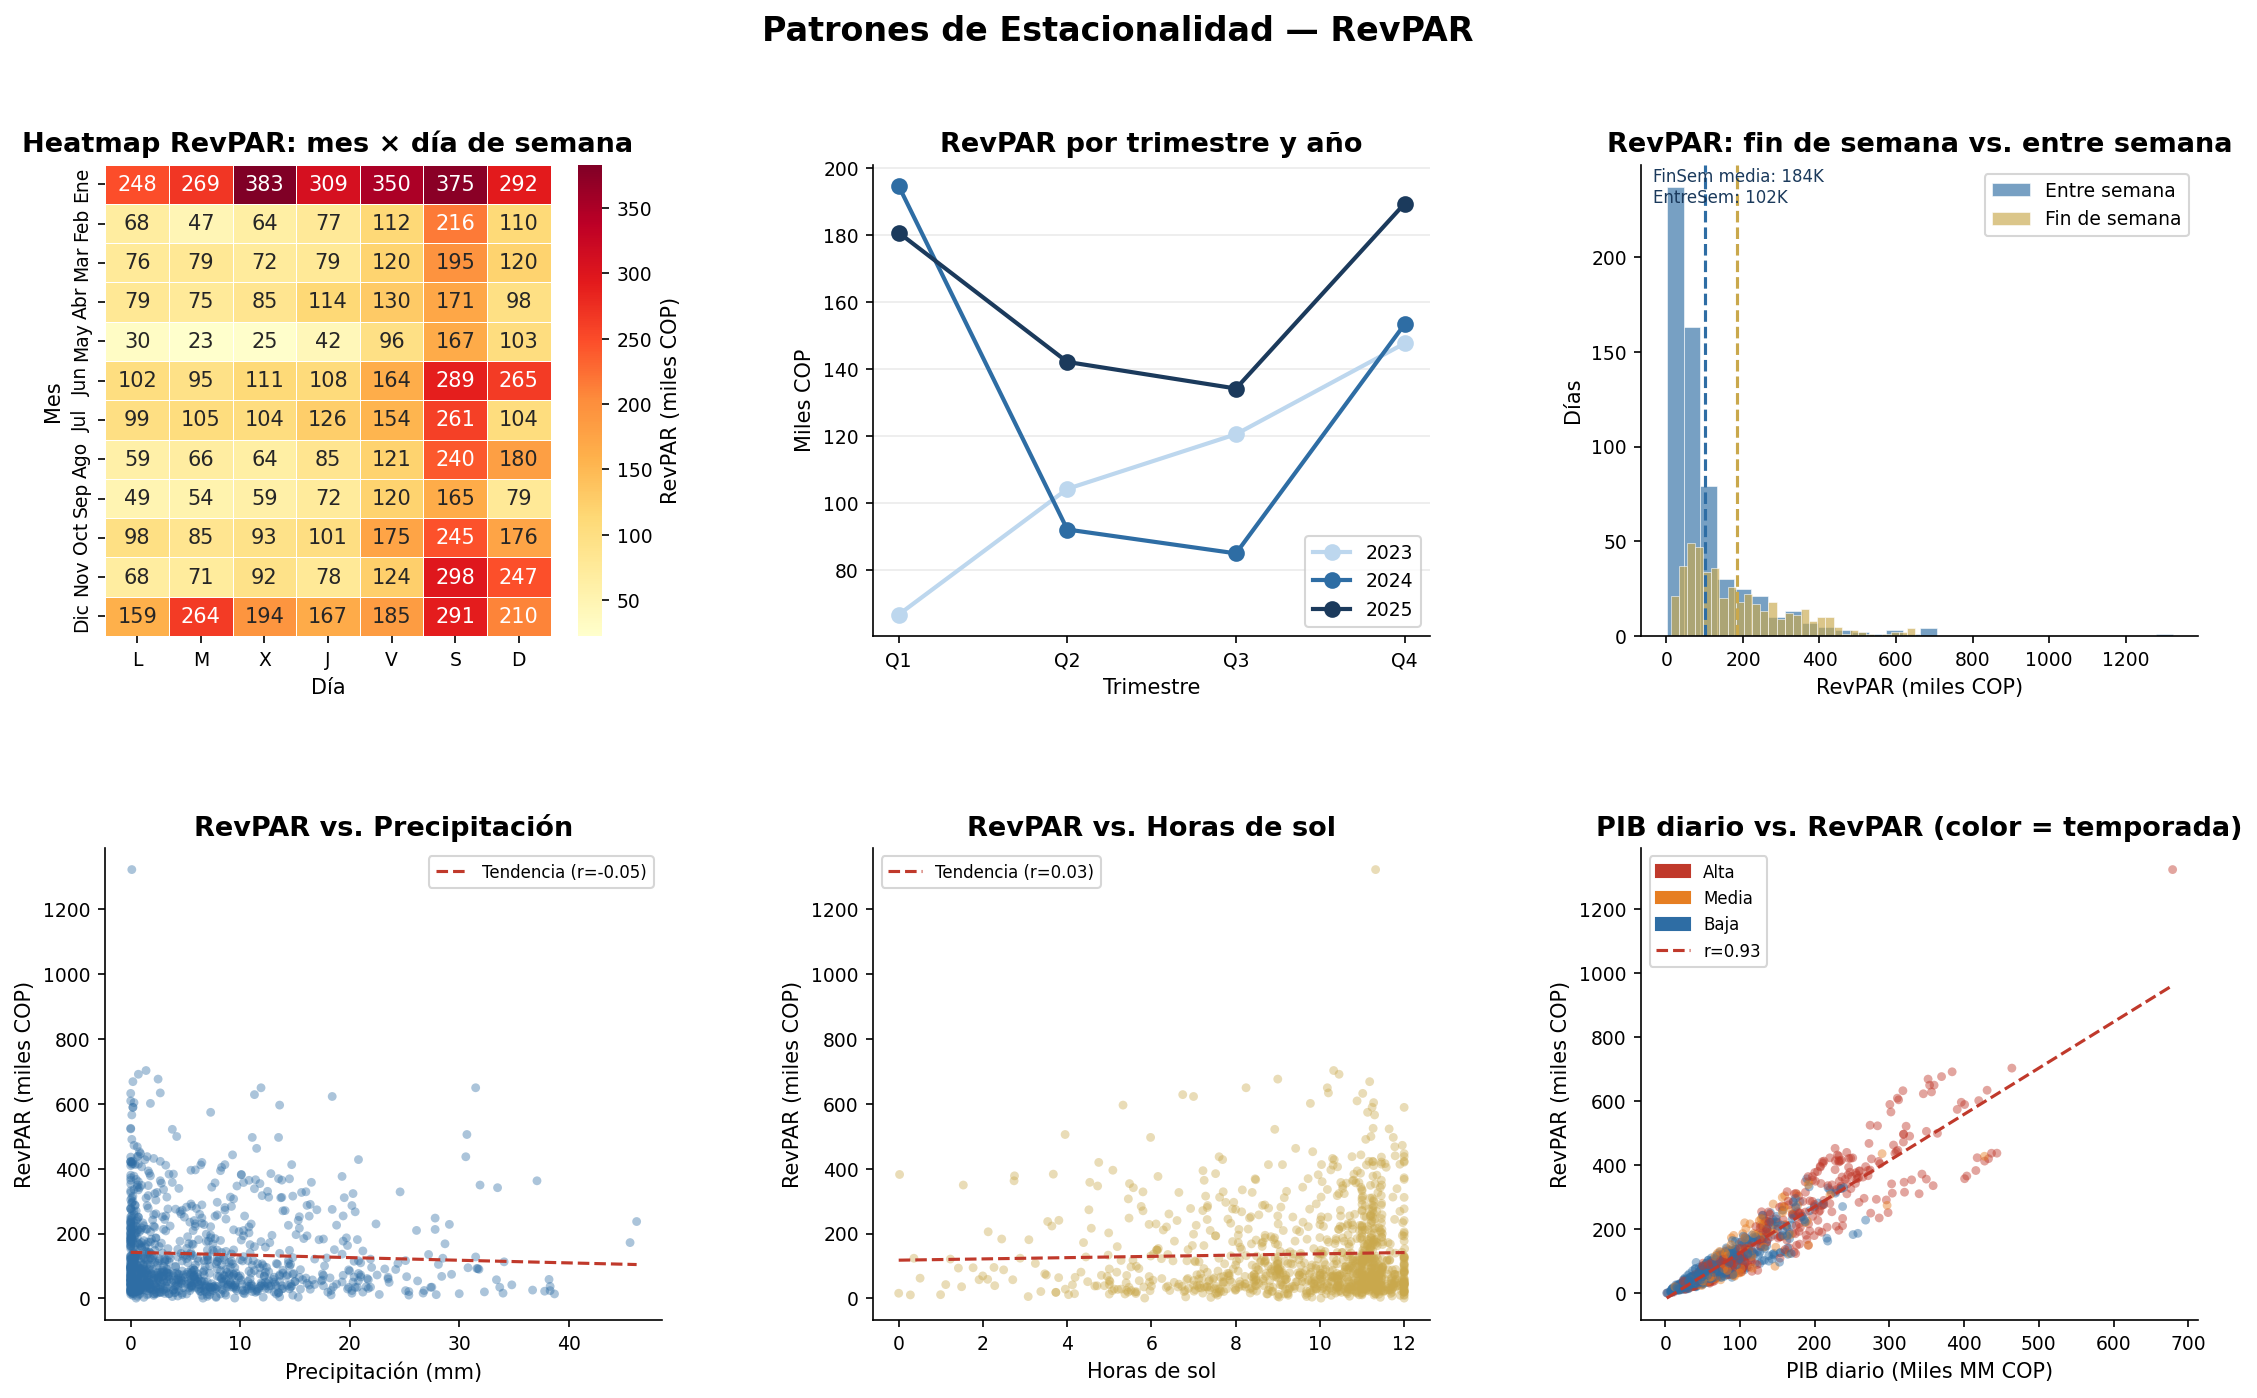

In [ ]:
from IPython.display import Image
Image('02_estacionalidad.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 4. PREPARACIÓN DE FEATURES
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  4. PREPARACIÓN DE FEATURES")
print("═"*62)

# Lags y medias móviles de RevPAR
df["revpar_lag1"]  = df["revpar"].shift(1)
df["revpar_lag7"]  = df["revpar"].shift(7)
df["revpar_lag14"] = df["revpar"].shift(14)
df["revpar_lag30"] = df["revpar"].shift(30)
df["revpar_ma7"]   = df["revpar"].shift(1).rolling(7).mean()
df["revpar_ma14"]  = df["revpar"].shift(1).rolling(14).mean()
df["revpar_ma30"]  = df["revpar"].shift(1).rolling(30).mean()
df["revpar_std7"]  = df["revpar"].shift(1).rolling(7).std()

df_clean = df.dropna().copy()

FEATURES = [
    # Calendáricas
    "dow", "mes", "dia_mes", "fin_semana", "temporada_num", "trimestre", "semana",
    "dow_sin", "dow_cos", "mes_sin", "mes_cos",
    # Climáticas
    "precipitacion_mm", "sol_horas",
    # Macroeconómica
    "PIB_diario_MMM",
    # Lags ocupación e ingresos
    "ocupacion_lag1", "ocupacion_lag7", "ocupacion_ma7",
    "ingresos_lag1", "ingresos_lag7", "ingresos_ma7",
    # Lags RevPAR
    "revpar_lag1", "revpar_lag7", "revpar_lag14", "revpar_lag30",
    "revpar_ma7", "revpar_ma14", "revpar_ma30", "revpar_std7",
]

TARGET = "revpar"
print(f"  Features totales: {len(FEATURES)}")
print(f"  Filas disponibles: {len(df_clean)}")

# Correlación features vs RevPAR
corrs = df_clean[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

# ── Figura preparación ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Preparación de features — Pronóstico RevPAR", fontsize=14, fontweight="bold")
plt.subplots_adjust(wspace=0.38)

# ── 4a. Correlación con RevPAR ────────────────────────────────────
ax = axes[0]
top_corr = corrs.head(15)
colors_c = [ROJO if v > 0.6 else DORADO if v > 0.3 else AZUL_MED for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors_c, edgecolor="white")
ax.set_title("Correlación |r| con RevPAR (top 15)")
ax.set_xlabel("|r| Pearson")
ax.axvline(0.3, color=GRIS, linestyle="--", linewidth=1, alpha=0.7, label="Umbral 0.3")
ax.axvline(0.6, color=ROJO, linestyle="--", linewidth=1, alpha=0.7, label="Umbral 0.6")
ax.legend(fontsize=8)

# ── 4b. Distribución RevPAR antes/después de log ─────────────────
ax = axes[1]
ax.hist(df_clean["revpar"] / 1e3, bins=40, color=AZUL_MED,
        alpha=0.7, edgecolor="white", label="RevPAR original")
ax2_twin = ax.twinx()
ax2_twin.hist(np.log1p(df_clean["revpar"] / 1e3), bins=40, color=DORADO,
              alpha=0.5, edgecolor="white", label="log(RevPAR)")
ax.set_title("Distribución RevPAR (original vs. log)")
ax.set_xlabel("RevPAR (miles COP)")
ax.set_ylabel("Frecuencia (original)", color=AZUL_MED)
ax2_twin.set_ylabel("Frecuencia (log)", color=DORADO)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

# ── 4c. Train/Test split visual ───────────────────────────────────
ax = axes[2]
train_data = df_clean[df_clean["año"] < 2025]
test_data  = df_clean[df_clean["año"] == 2025]
ax.fill_between(train_data["fecha_noche"], train_data["revpar"] / 1e3,
                alpha=0.5, color=AZUL_MED, label=f"Train ({len(train_data)} días)")
ax.fill_between(test_data["fecha_noche"],  test_data["revpar"] / 1e3,
                alpha=0.5, color=DORADO,   label=f"Test ({len(test_data)} días)")
ax.plot(df_clean["fecha_noche"], df_clean["revpar"] / 1e3,
        color=AZUL, linewidth=0.8, alpha=0.7)
ax.axvline(pd.Timestamp("2025-01-01"), color=ROJO, linestyle="--", linewidth=1.5,
           label="Corte train/test")
ax.set_title("Partición Train (2023–2024) / Test (2025)")
ax.set_ylabel("RevPAR (miles COP)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)

plt.savefig("03_preparacion_features.png")
plt.close()
print("  ✓ 03_preparacion_features.png")


══════════════════════════════════════════════════════════════
  4. PREPARACIÓN DE FEATURES
══════════════════════════════════════════════════════════════
  Features totales: 28
  Filas disponibles: 1028
  ✓ 03_preparacion_features.png


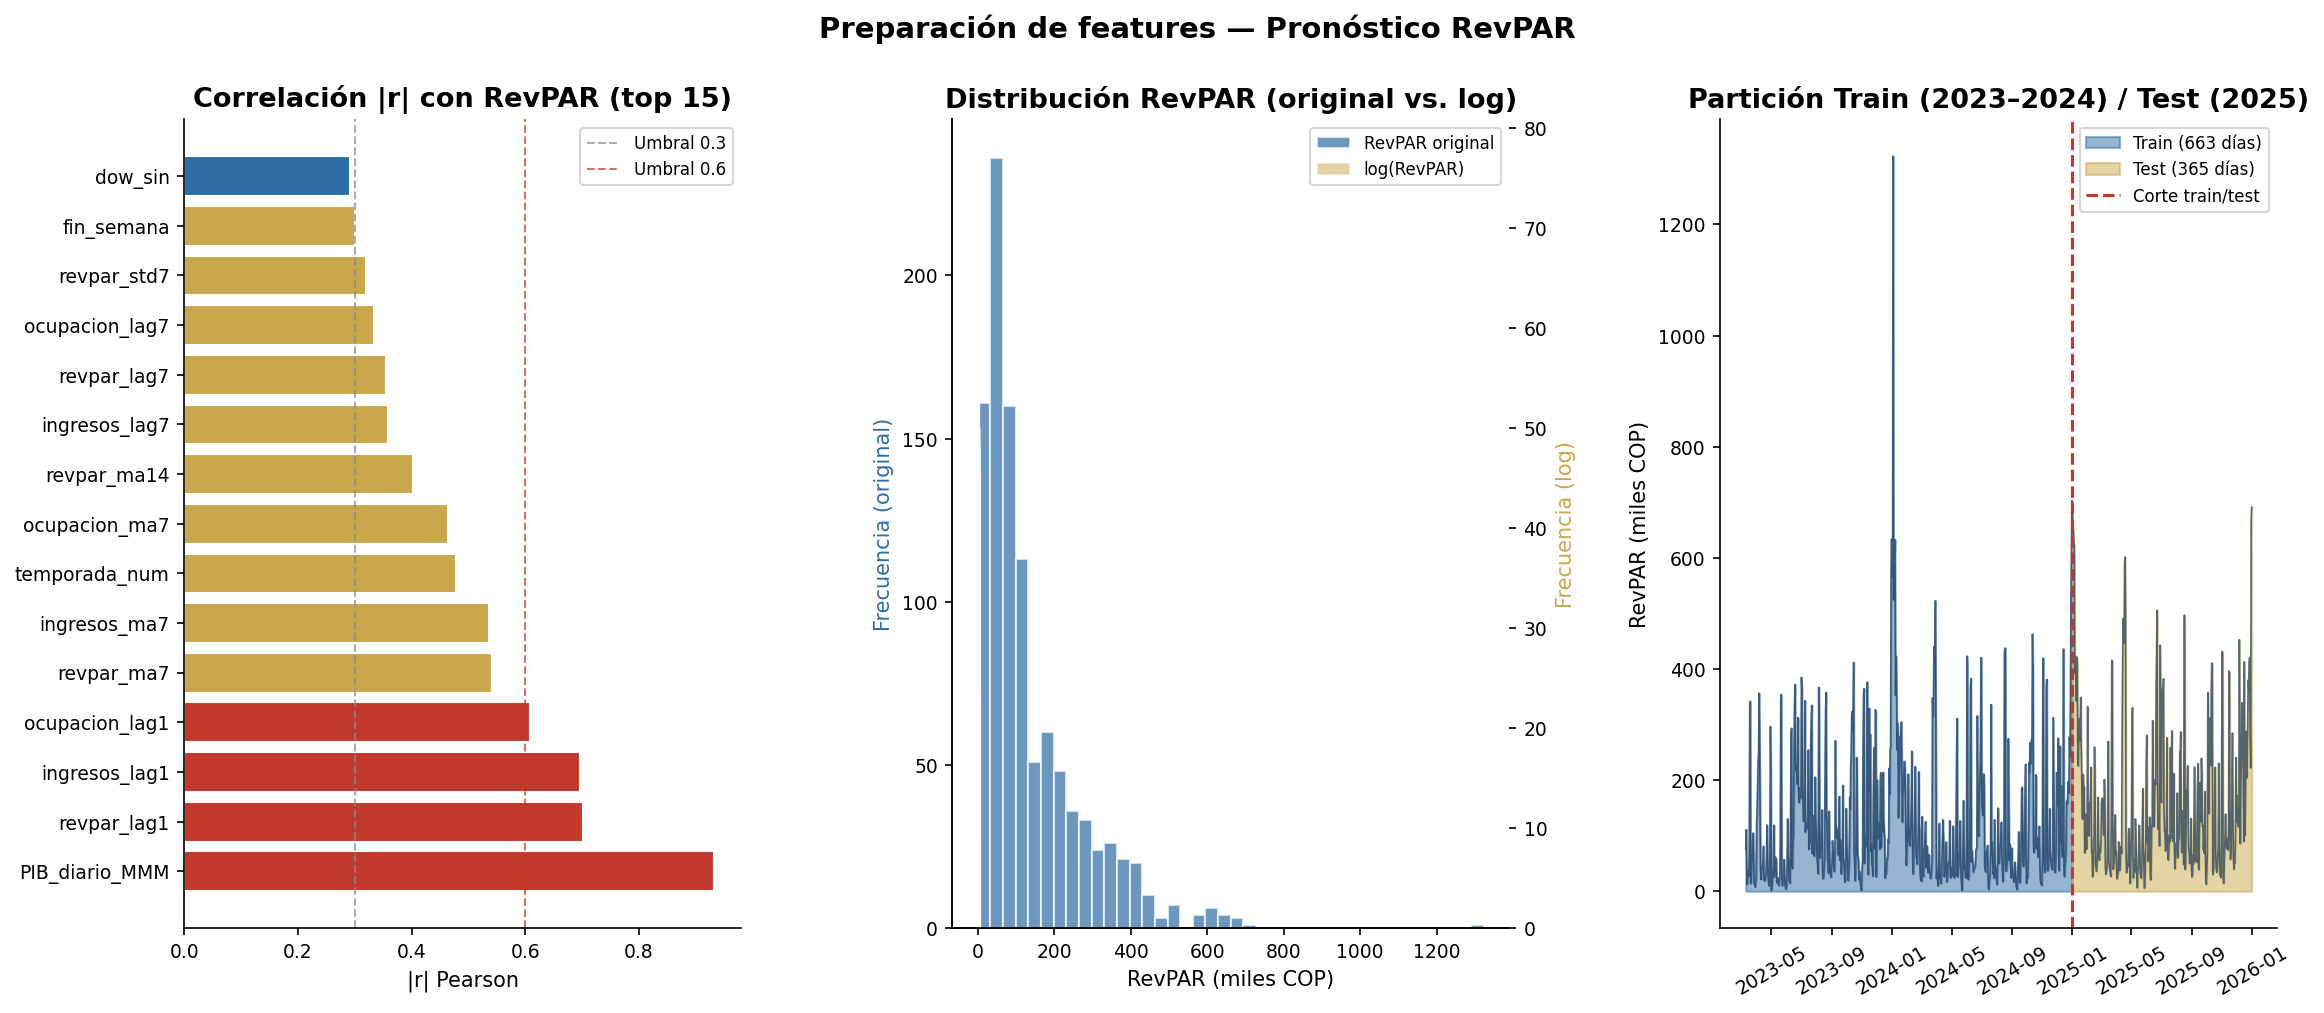

In [ ]:
from IPython.display import Image
Image('03_preparacion_features.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  5. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS")
print("═"*62)

train = df_clean[df_clean["año"] < 2025].copy()
test  = df_clean[df_clean["año"] == 2025].copy()
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"  Train: {len(train)} días | Test: {len(test)} días")

# Definir modelos
MODELS = {
    "Ridge":            Ridge(alpha=500),
    "Lasso":            Lasso(alpha=5000, max_iter=10000),
    "Random Forest":    RandomForestRegressor(n_estimators=500, max_depth=12,
                                              min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Gradient Boosting":GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                   max_depth=5, random_state=42),
    "XGBoost":          XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                     random_state=42, verbosity=0, n_jobs=-1),
}

# Escalar para modelos lineales
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

resultados = {}
predicciones = {}

for name, model in MODELS.items():
    if name in ("Ridge", "Lasso"):
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    resultados[name] = {"MAPE": mape, "R2": r2, "MAE": mae, "RMSE": rmse}
    predicciones[name] = pred
    print(f"  {name:<20}  MAPE={mape*100:.2f}%  R²={r2:.4f}  MAE={mae:,.0f}")

# Modelo ganador
best_model_name = min(resultados, key=lambda x: resultados[x]["MAPE"])
print(f"\n  ► Modelo seleccionado: {best_model_name}  (MAPE={resultados[best_model_name]['MAPE']*100:.2f}%)")
best_pred = predicciones[best_model_name]
best_model = MODELS[best_model_name]

# ── Figura comparación de modelos ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparación de Modelos — RevPAR", fontsize=15, fontweight="bold")
plt.subplots_adjust(hspace=0.4, wspace=0.35)

MOD_COLORS = {
    "Ridge":            "#8A8A8A",
    "Lasso":            AZUL_CLARO,
    "Random Forest":    AZUL_MED,
    "Gradient Boosting":DORADO,
    "XGBoost":          ROJO,
}

# ── 5a. MAPE por modelo ───────────────────────────────────────────
ax = axes[0, 0]
names  = list(resultados.keys())
mapes  = [resultados[n]["MAPE"] * 100 for n in names]
colors_m = [ROJO if n == best_model_name else MOD_COLORS[n] for n in names]
bars = ax.bar(names, mapes, color=colors_m, edgecolor="white")
ax.set_title("MAPE por modelo (menor = mejor)")
ax.set_ylabel("MAPE (%)")
ax.set_xticklabels(names, rotation=25, ha="right")
ax.axhline(20, color=GRIS, linestyle="--", linewidth=1, label="Umbral 20%")
ax.legend(fontsize=8)
for b, v in zip(bars, mapes):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
            f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

# ── 5b. R² por modelo ────────────────────────────────────────────
ax = axes[0, 1]
r2s = [resultados[n]["R2"] for n in names]
bars = ax.bar(names, r2s, color=colors_m, edgecolor="white")
ax.set_title("R² por modelo (mayor = mejor)")
ax.set_ylabel("R²")
ax.set_ylim(0, 1.1)
ax.set_xticklabels(names, rotation=25, ha="right")
ax.axhline(0.85, color=GRIS, linestyle="--", linewidth=1, label="Umbral 0.85")
ax.legend(fontsize=8)
for b, v in zip(bars, r2s):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# ── 5c. Predicción vs Real (mejor modelo) ────────────────────────
ax = axes[1, 0]
ax.plot(test["fecha_noche"], y_test.values / 1e3,
        color=AZUL, linewidth=1.8, label="Real", alpha=0.9)
ax.plot(test["fecha_noche"], best_pred / 1e3,
        color=ROJO, linewidth=1.4, linestyle="--",
        label=f"Predicho ({best_model_name})", alpha=0.9)
ax.fill_between(test["fecha_noche"],
                (best_pred * 0.85) / 1e3, (best_pred * 1.15) / 1e3,
                alpha=0.12, color=ROJO, label="±15% intervalo")
ax.set_title(f"Predicción vs. Real — {best_model_name}")
ax.set_ylabel("RevPAR (miles COP)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25)

# ── 5d. Scatter Real vs Predicho ─────────────────────────────────
ax = axes[1, 1]
ax.scatter(y_test.values / 1e3, best_pred / 1e3,
           color=AZUL_MED, alpha=0.5, s=20, edgecolors="none")
mn = min(y_test.min(), best_pred.min()) / 1e3
mx = max(y_test.max(), best_pred.max()) / 1e3
ax.plot([mn, mx], [mn, mx], color=ROJO, linestyle="--", linewidth=1.5, label="Perfecto")
ax.set_title(f"Real vs. Predicho — {best_model_name}\nMAPE={resultados[best_model_name]['MAPE']*100:.1f}%  R²={resultados[best_model_name]['R2']:.3f}")
ax.set_xlabel("RevPAR Real (miles COP)")
ax.set_ylabel("RevPAR Predicho (miles COP)")
ax.legend(fontsize=8)

plt.savefig("04_comparacion_modelos.png")
plt.close()
print("  ✓ 04_comparacion_modelos.png")


══════════════════════════════════════════════════════════════
  5. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS
══════════════════════════════════════════════════════════════
  Train: 663 días | Test: 365 días
  Ridge                 MAPE=38.01%  R²=0.7802  MAE=44,415
  Lasso                 MAPE=25.44%  R²=0.9086  MAE=28,406
  Random Forest         MAPE=15.55%  R²=0.9353  MAE=23,860
  Gradient Boosting     MAPE=17.10%  R²=0.9286  MAE=25,405
  XGBoost               MAPE=16.88%  R²=0.9096  MAE=26,307

  ► Modelo seleccionado: Random Forest  (MAPE=15.55%)
  ✓ 04_comparacion_modelos.png


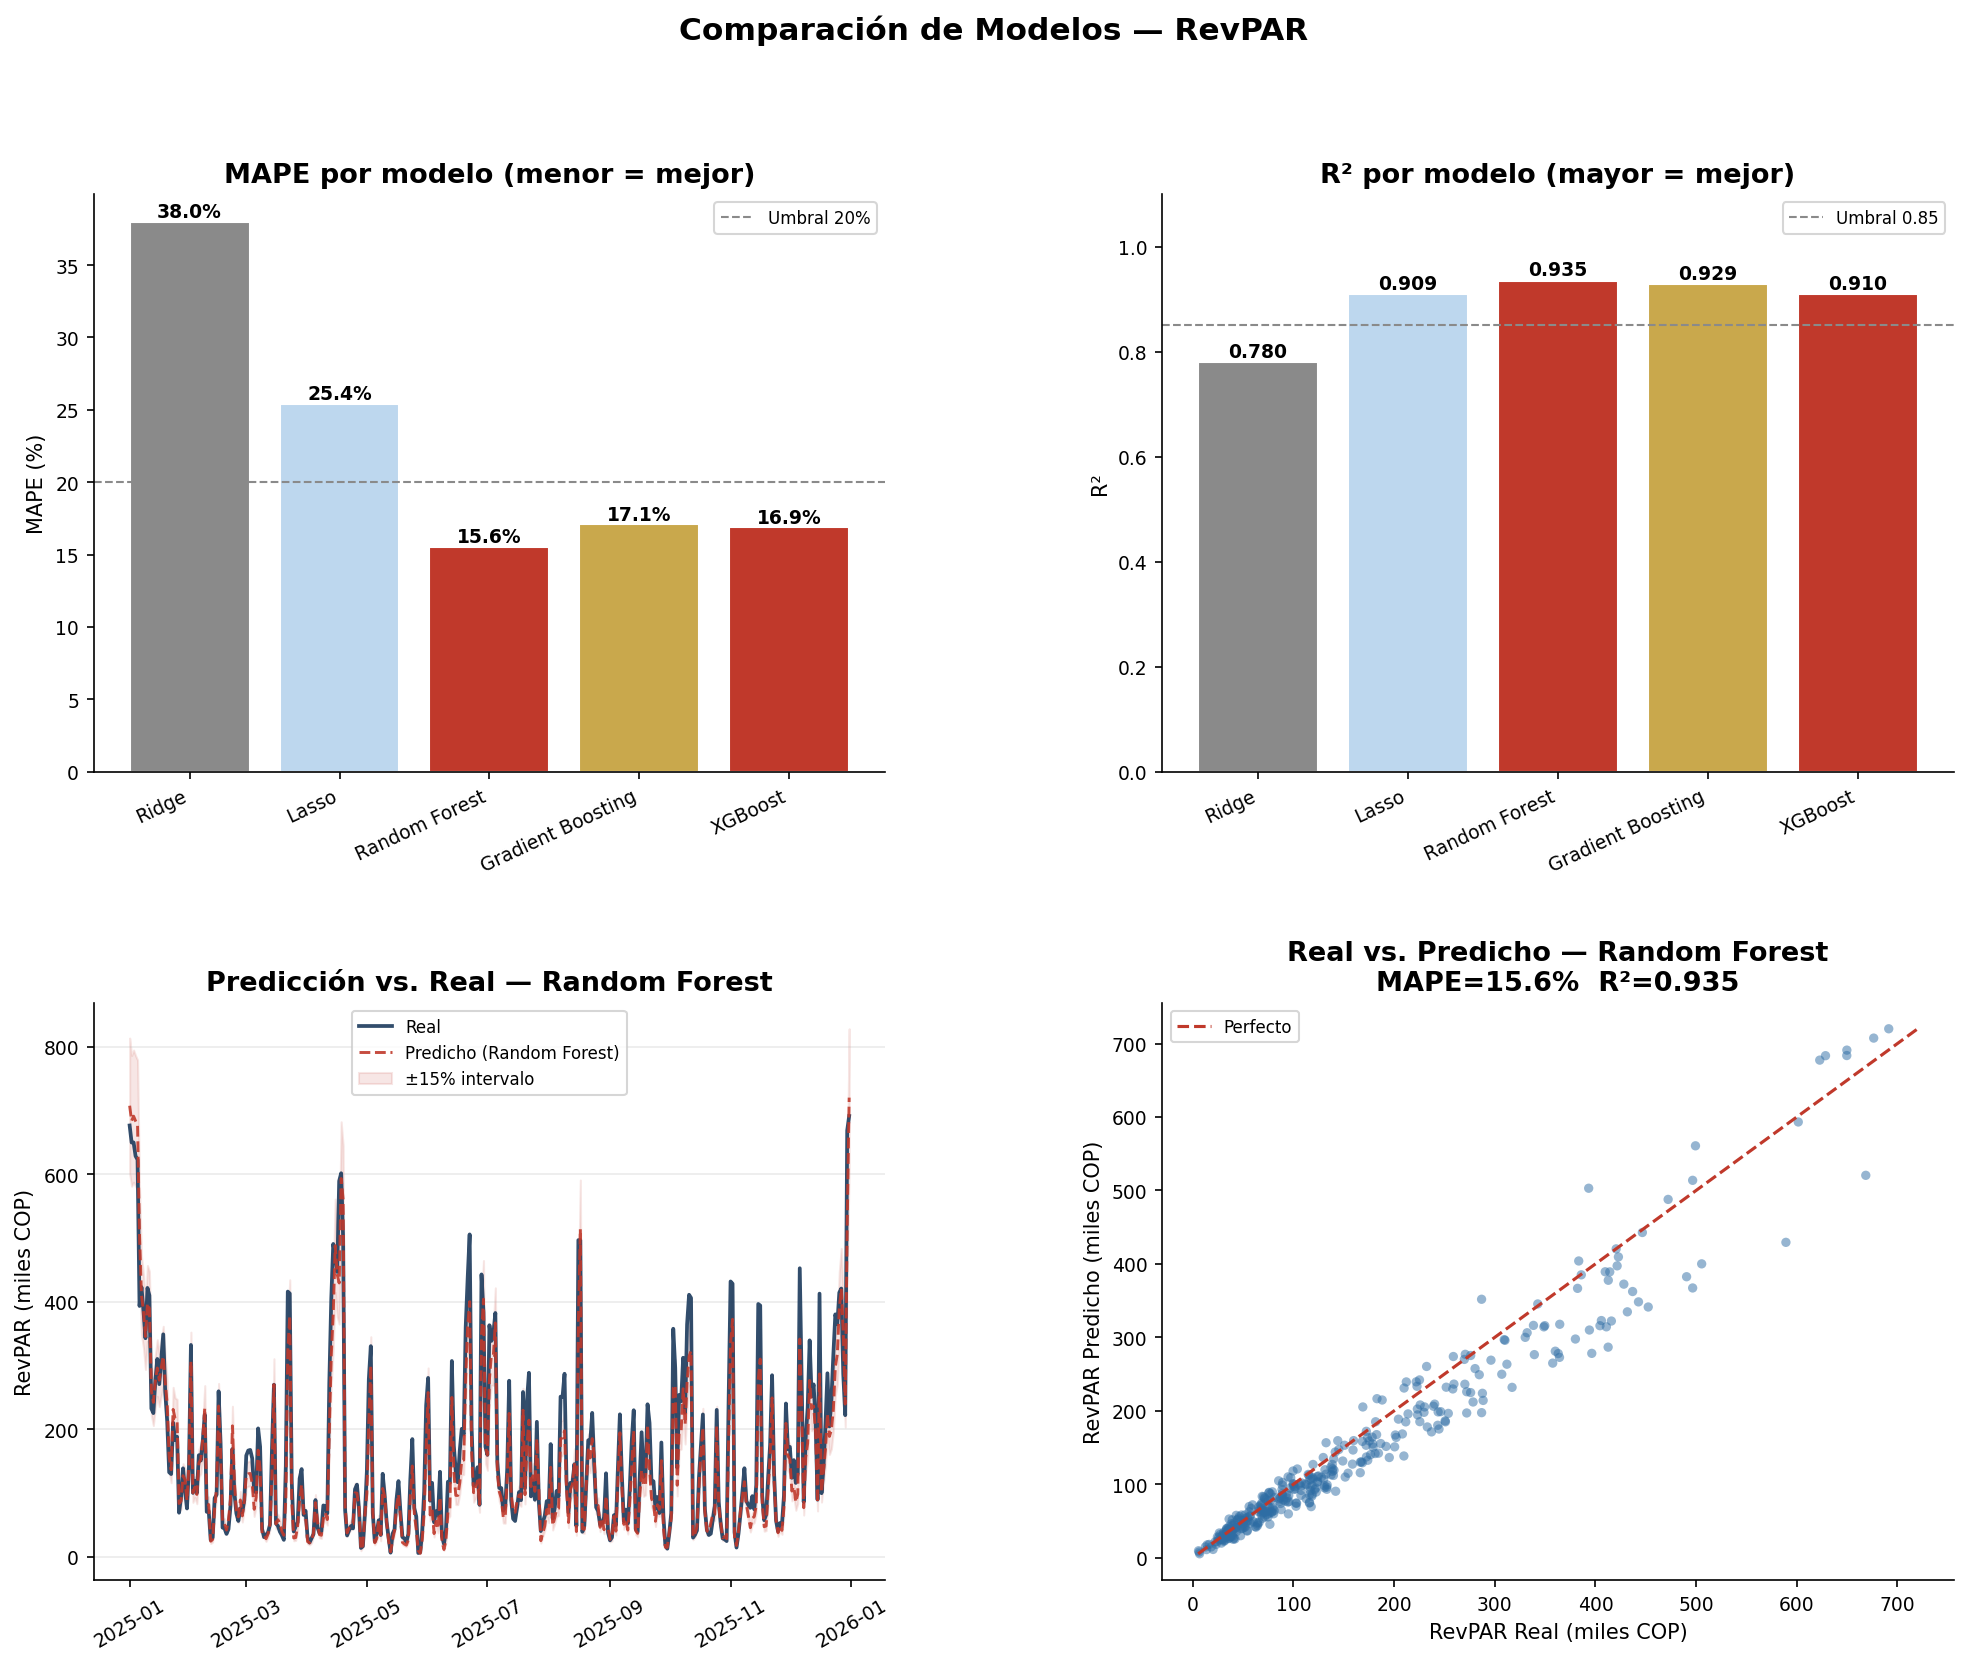

In [ ]:
from IPython.display import Image
Image('04_comparacion_modelos.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6. DIAGNÓSTICO DEL MODELO GANADOR
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  6. DIAGNÓSTICO DEL MODELO")
print("═"*62)

residuals = y_test.values - best_pred
pct_errors = (residuals / y_test.values) * 100

# Importancia de variables (si el modelo lo soporta)
has_importance = hasattr(best_model, "feature_importances_")
if has_importance:
    imp = pd.DataFrame({
        "feature": FEATURES,
        "importancia": best_model.feature_importances_
    }).sort_values("importancia", ascending=False).reset_index(drop=True)

# Validación cruzada temporal (TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=5)
cv_mapes = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(df_clean[FEATURES])):
    X_tr_cv = df_clean[FEATURES].iloc[tr_idx]
    y_tr_cv = df_clean[TARGET].iloc[tr_idx]
    X_te_cv = df_clean[FEATURES].iloc[te_idx]
    y_te_cv = df_clean[TARGET].iloc[te_idx]
    m = RandomForestRegressor(n_estimators=300, max_depth=12,
                               min_samples_leaf=3, random_state=42, n_jobs=-1)
    m.fit(X_tr_cv, y_tr_cv)
    p_cv = m.predict(X_te_cv)
    cv_mapes.append(mean_absolute_percentage_error(y_te_cv, p_cv))

print(f"  CV MAPE (5-fold TS):  {np.mean(cv_mapes)*100:.2f}% ± {np.std(cv_mapes)*100:.2f}%")

# ── Figura diagnóstico ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle(f"Diagnóstico del Modelo — {best_model_name}", fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── 6a. Importancia de variables ─────────────────────────────────
ax = fig.add_subplot(gs[0, :2])
if has_importance:
    top15 = imp.head(15)
    TIPO_MAP = {
        "dow":"Calendárica","mes":"Calendárica","dia_mes":"Calendárica",
        "fin_semana":"Calendárica","temporada_num":"Calendárica","trimestre":"Calendárica",
        "semana":"Calendárica","dow_sin":"Calendárica","dow_cos":"Calendárica",
        "mes_sin":"Calendárica","mes_cos":"Calendárica",
        "precipitacion_mm":"Climática","sol_horas":"Climática",
        "PIB_diario_MMM":"Macroeconómica",
        "ocupacion_lag1":"Lag Ocupación","ocupacion_lag7":"Lag Ocupación","ocupacion_ma7":"Lag Ocupación",
        "ingresos_lag1":"Lag Ingresos","ingresos_lag7":"Lag Ingresos","ingresos_ma7":"Lag Ingresos",
        "revpar_lag1":"Lag RevPAR","revpar_lag7":"Lag RevPAR","revpar_lag14":"Lag RevPAR",
        "revpar_lag30":"Lag RevPAR","revpar_ma7":"Lag RevPAR","revpar_ma14":"Lag RevPAR",
        "revpar_ma30":"Lag RevPAR","revpar_std7":"Lag RevPAR",
    }
    TIPO_COL = {
        "Calendárica":    AZUL_MED,
        "Climática":      VERDE,
        "Macroeconómica": ROJO,
        "Lag Ocupación":  DORADO,
        "Lag Ingresos":   "#5A4E9E",
        "Lag RevPAR":     AZUL,
    }
    top15["tipo"]  = top15["feature"].map(TIPO_MAP).fillna("Otro")
    top15["color"] = top15["tipo"].map(TIPO_COL)
    ax.barh(top15["feature"], top15["importancia"] * 100,
            color=top15["color"], edgecolor="white")
    ax.set_title("Importancia de variables (top 15)")
    ax.set_xlabel("Importancia (%)")
    handles = [mpatches.Patch(color=c, label=t)
               for t, c in TIPO_COL.items()
               if t in top15["tipo"].values]
    ax.legend(handles=handles, fontsize=8, loc="lower right")

# ── 6b. Validación cruzada temporal ──────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.bar(range(1, 6), [v * 100 for v in cv_mapes],
       color=[ROJO if v == max(cv_mapes) else AZUL_MED for v in cv_mapes],
       edgecolor="white")
ax.axhline(np.mean(cv_mapes) * 100, color=DORADO, linestyle="--", linewidth=1.5,
           label=f"Media: {np.mean(cv_mapes)*100:.1f}%")
ax.set_title("MAPE por fold (CV temporal)")
ax.set_xlabel("Fold")
ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8)
for i, v in enumerate(cv_mapes):
    ax.text(i + 1, v * 100 + 0.2, f"{v*100:.1f}%", ha="center", fontsize=8)

# ── 6c. Residuos en el tiempo ─────────────────────────────────────
ax = fig.add_subplot(gs[1, :2])
ax.bar(test["fecha_noche"], residuals / 1e3,
       color=[ROJO if r < 0 else VERDE for r in residuals],
       width=1, alpha=0.7)
ax.axhline(0, color=AZUL, linewidth=1.2)
ax.set_title("Residuos en el tiempo (real − predicho)")
ax.set_ylabel("Error (miles COP)")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)

# ── 6d. Distribución de residuos ─────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.hist(residuals / 1e3, bins=30, color=AZUL_MED, edgecolor="white", alpha=0.8)
ax.axvline(0, color=ROJO, linestyle="--", linewidth=1.5)
ax.axvline(np.mean(residuals) / 1e3, color=DORADO, linestyle="--", linewidth=1.5,
           label=f"Media: {np.mean(residuals)/1e3:.0f}K")
ax.set_title("Distribución de residuos")
ax.set_xlabel("Error (miles COP)")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=8)

# ── 6e. Error porcentual por mes ──────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
test_copy = test.copy()
test_copy["pct_error"] = pct_errors
mape_mes = test_copy.groupby("mes")["pct_error"].apply(lambda x: np.mean(np.abs(x)))
mes_disp = [mes_lbl[m - 1] for m in mape_mes.index]
ax.bar(mes_disp, mape_mes.values,
       color=[ROJO if v > 20 else DORADO if v > 10 else AZUL_MED for v in mape_mes.values],
       edgecolor="white")
ax.axhline(20, color=ROJO, linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("MAPE promedio por mes (2025)")
ax.set_ylabel("MAPE (%)")
ax.tick_params(axis="x", rotation=30)

# ── 6f. Error porcentual por temporada ───────────────────────────
ax = fig.add_subplot(gs[2, 1])
mape_temp = test_copy.groupby("temporada")["pct_error"].apply(lambda x: np.mean(np.abs(x)))
bars_t = ax.bar(mape_temp.index, mape_temp.values,
                color=[TEMP_PAL[t] for t in mape_temp.index], edgecolor="white")
ax.set_title("MAPE por temporada")
ax.set_ylabel("MAPE (%)")
for b, v in zip(bars_t, mape_temp.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3,
            f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

# ── 6g. Métricas resumen ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")
met_res = resultados[best_model_name]
tabla = [
    ["Métrica",           "Valor",                "Estado"],
    ["MAPE (test 2025)",  f"{met_res['MAPE']*100:.1f}%",  "✓" if met_res["MAPE"] < 0.20 else "~"],
    ["R² (test 2025)",    f"{met_res['R2']:.4f}",          "✓" if met_res["R2"] > 0.85 else "~"],
    ["MAE",               f"{met_res['MAE']/1e3:,.0f}K",   ""],
    ["RMSE",              f"{met_res['RMSE']/1e3:,.0f}K",  ""],
    ["CV MAPE (5-fold)",  f"{np.mean(cv_mapes)*100:.1f}%", ""],
    ["RevPAR baseline",   f"{revpar_2024/1e3:,.0f}K",      ""],
    ["Meta RevPAR (+5%)", f"{meta_revpar/1e3:,.0f}K",      ""],
]
t = ax.table(cellText=tabla[1:], colLabels=tabla[0],
             loc="center", cellLoc="center")
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.6)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor(AZUL)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 1:
        cell.set_facecolor("#F2F2F2")
    cell.set_edgecolor("white")
ax.set_title(f"Métricas — {best_model_name}", pad=10)

plt.savefig("05_diagnostico_modelo.png")
plt.close()
print("  ✓ 05_diagnostico_modelo.png")



══════════════════════════════════════════════════════════════
  6. DIAGNÓSTICO DEL MODELO
══════════════════════════════════════════════════════════════
  CV MAPE (5-fold TS):  25.38% ± 9.92%
  ✓ 05_diagnostico_modelo.png


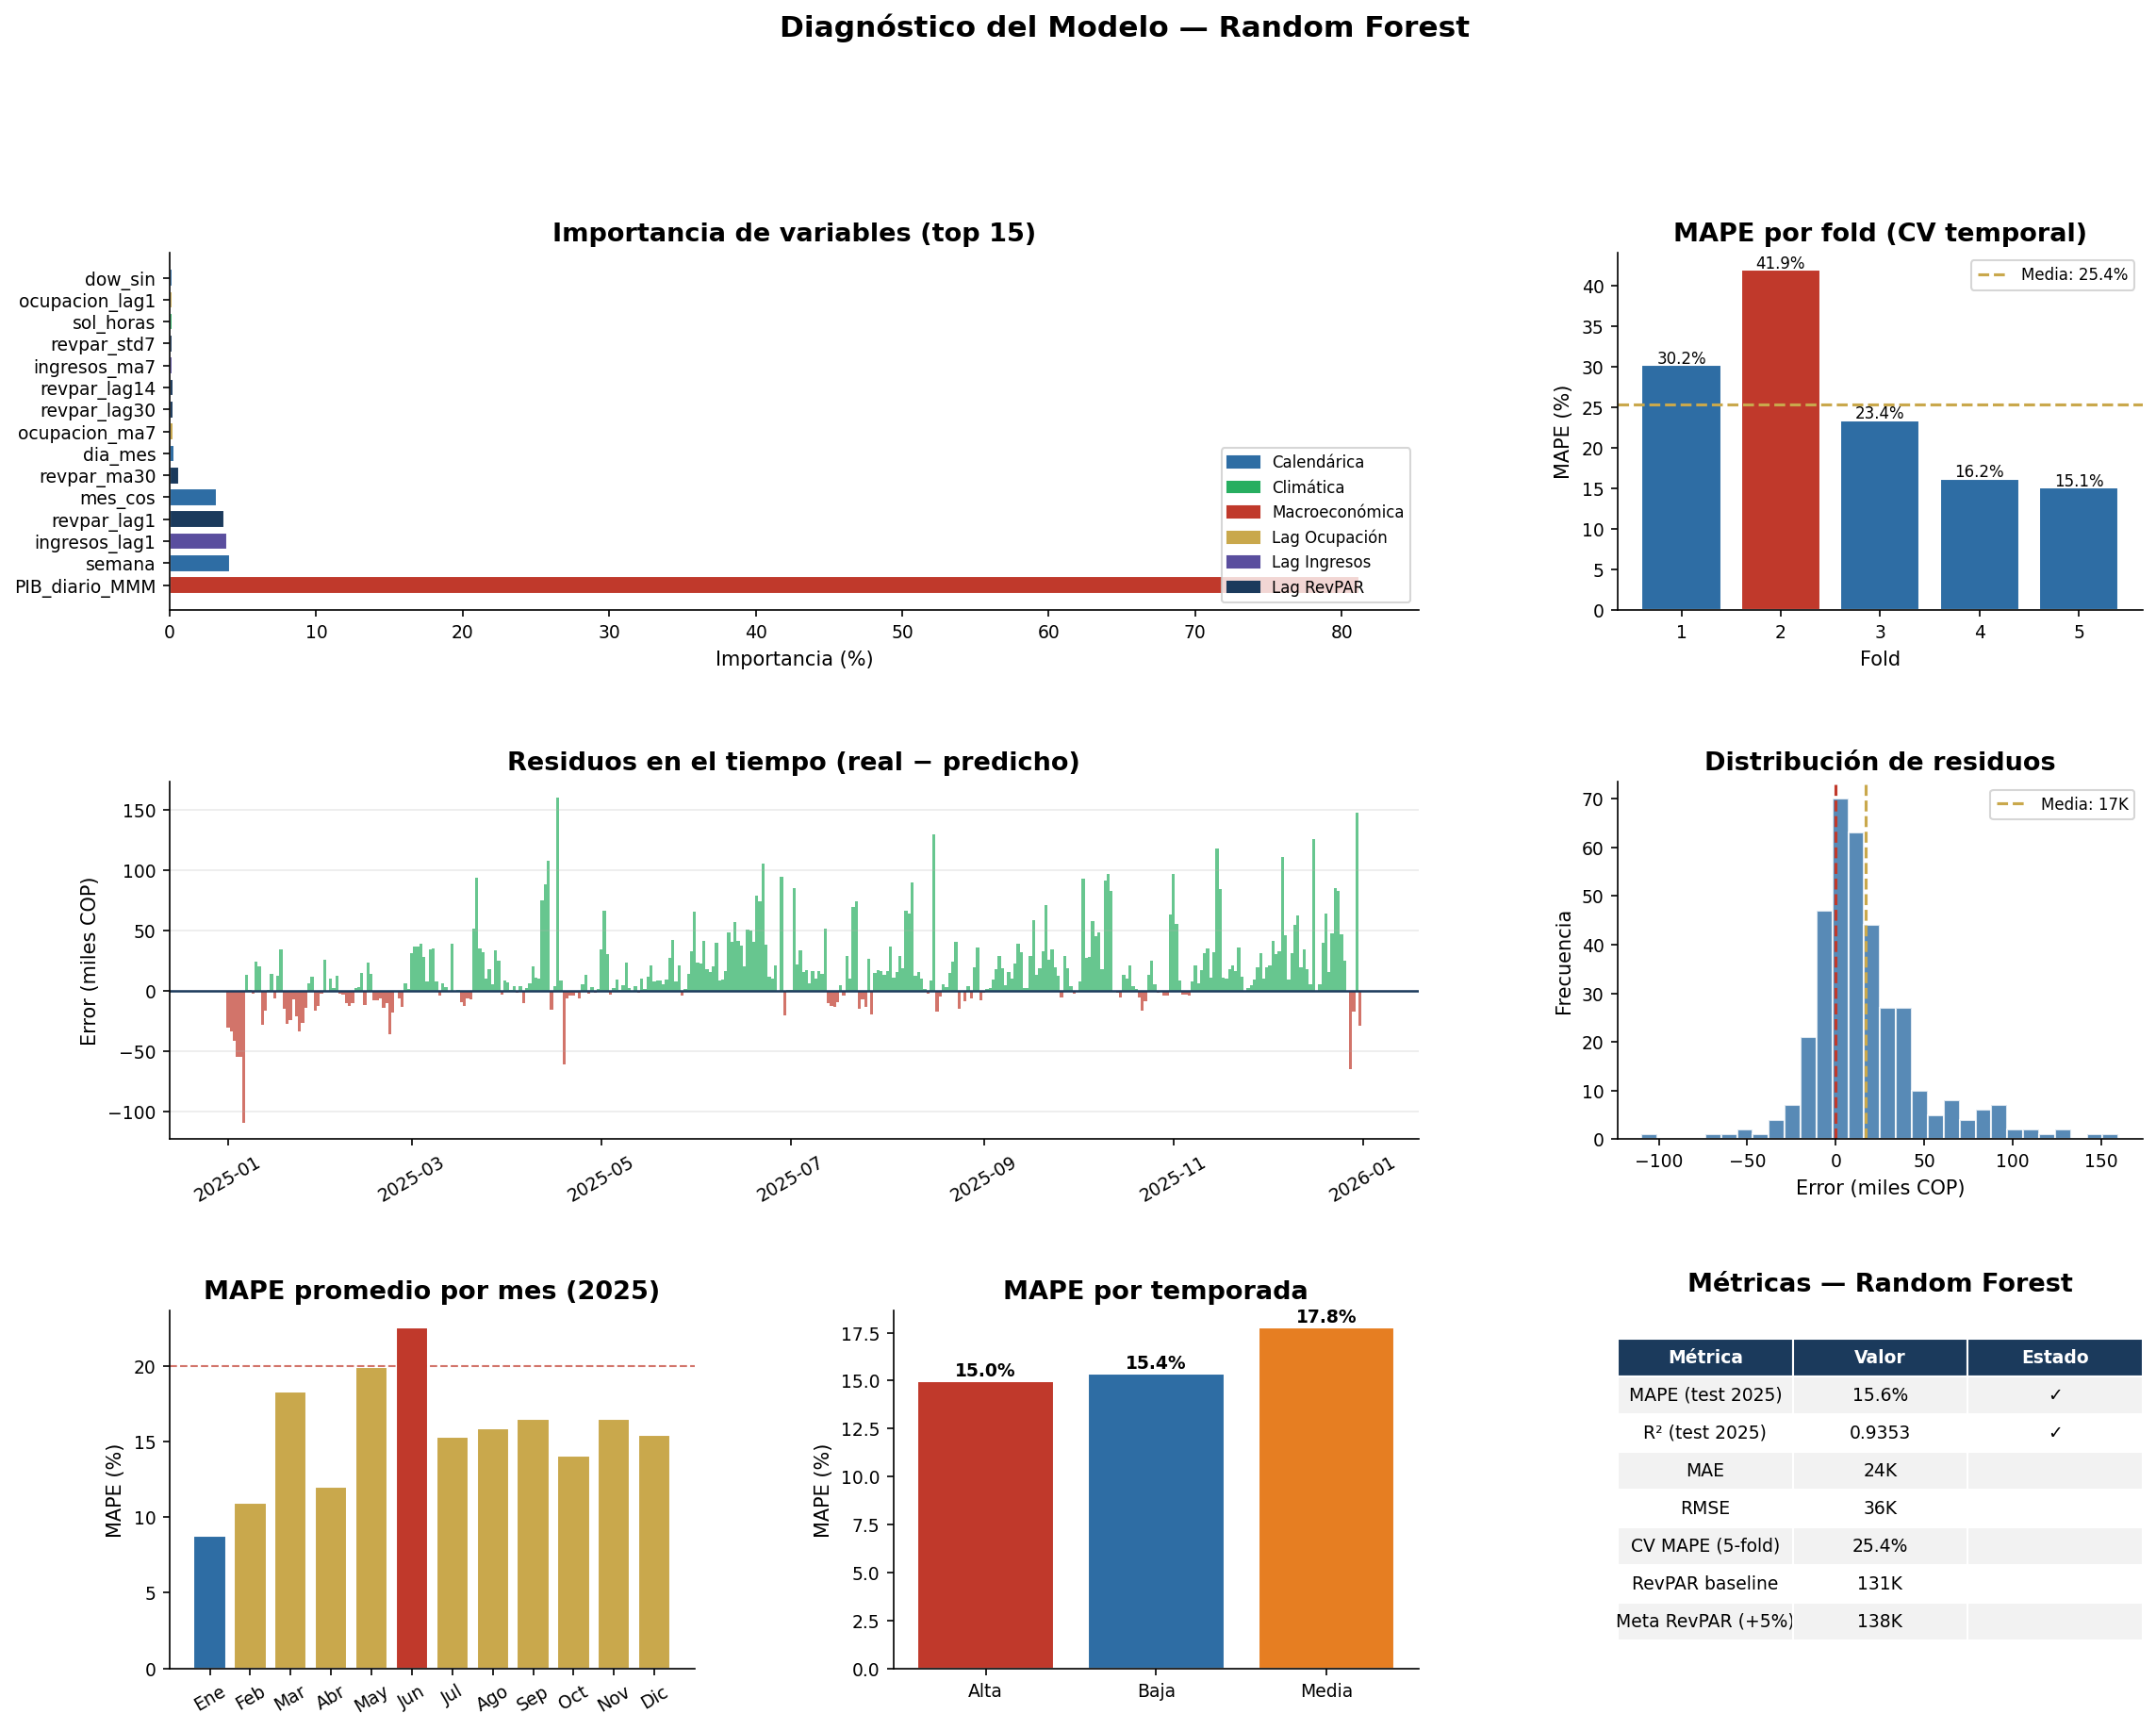

In [ ]:
from IPython.display import Image
Image('05_diagnostico_modelo.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 7. PRONÓSTICO 2026 (Primer semestre)
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  7. PRONÓSTICO 2026")
print("═"*62)

# Construir fechas futuras: ene-jun 2026
future_dates = pd.date_range("2026-01-01", "2026-06-30", freq="D")
future = pd.DataFrame({"fecha_noche": future_dates})
future["dow"]        = future["fecha_noche"].dt.dayofweek
future["mes"]        = future["fecha_noche"].dt.month
future["dia_mes"]    = future["fecha_noche"].dt.day
future["fin_semana"] = (future["dow"] >= 5).astype(int)
future["trimestre"]  = future["fecha_noche"].dt.quarter
future["semana"]     = future["fecha_noche"].dt.isocalendar().week.astype(int)
future["año"]        = 2026

# Temporada (mapeo manual basado en histórico)
def asignar_temporada(mes):
    if mes in [6, 7, 12]: return 2   # Alta
    if mes in [3, 4, 11]: return 1   # Media
    return 0                          # Baja

future["temporada_num"] = future["mes"].apply(asignar_temporada)
future["temporada"]     = future["temporada_num"].map({2:"Alta", 1:"Media", 0:"Baja"})

# Encoding cíclico
future["dow_sin"] = np.sin(2 * np.pi * future["dow"] / 7)
future["dow_cos"] = np.cos(2 * np.pi * future["dow"] / 7)
future["mes_sin"] = np.sin(2 * np.pi * future["mes"] / 12)
future["mes_cos"] = np.cos(2 * np.pi * future["mes"] / 12)

# Variables climáticas: usar medias históricas por mes/día semana
clima_hist = df.groupby(["mes","dow"])[["precipitacion_mm","sol_horas","PIB_diario_MMM"]].mean().reset_index()
future = future.merge(clima_hist, on=["mes","dow"], how="left")

# Lags: usar últimos valores reales del dataset (diciembre 2025)
# Para pronóstico iterativo usamos medias móviles del último mes conocido
last_30 = df_clean.tail(30)
lag_vals = {
    "ocupacion_lag1": last_30["ocupacion"].iloc[-1],
    "ocupacion_lag7": last_30["ocupacion"].iloc[-7],
    "ocupacion_ma7":  last_30["ocupacion"].tail(7).mean(),
    "ingresos_lag1":  last_30["ingresos"].iloc[-1],
    "ingresos_lag7":  last_30["ingresos"].iloc[-7],
    "ingresos_ma7":   last_30["ingresos"].tail(7).mean(),
    "revpar_lag1":    last_30["revpar"].iloc[-1],
    "revpar_lag7":    last_30["revpar"].iloc[-7],
    "revpar_lag14":   last_30["revpar"].iloc[-14],
    "revpar_lag30":   last_30["revpar"].iloc[-30],
    "revpar_ma7":     last_30["revpar"].tail(7).mean(),
    "revpar_ma14":    last_30["revpar"].tail(14).mean(),
    "revpar_ma30":    last_30["revpar"].tail(30).mean(),
    "revpar_std7":    last_30["revpar"].tail(7).std(),
}

# Pronóstico iterativo: actualizar lags con predicciones previas
pred_buffer = list(last_30["revpar"].values)
preds_2026 = []

for i, row in future.iterrows():
    row_feats = {
        "dow": row["dow"], "mes": row["mes"], "dia_mes": row["dia_mes"],
        "fin_semana": row["fin_semana"], "temporada_num": row["temporada_num"],
        "trimestre": row["trimestre"], "semana": row["semana"],
        "dow_sin": row["dow_sin"], "dow_cos": row["dow_cos"],
        "mes_sin": row["mes_sin"], "mes_cos": row["mes_cos"],
        "precipitacion_mm": row["precipitacion_mm"], "sol_horas": row["sol_horas"],
        "PIB_diario_MMM": row["PIB_diario_MMM"],
        "ocupacion_lag1": lag_vals["ocupacion_lag1"],
        "ocupacion_lag7": lag_vals["ocupacion_lag7"],
        "ocupacion_ma7":  lag_vals["ocupacion_ma7"],
        "ingresos_lag1":  lag_vals["ingresos_lag1"],
        "ingresos_lag7":  lag_vals["ingresos_lag7"],
        "ingresos_ma7":   lag_vals["ingresos_ma7"],
        "revpar_lag1":  pred_buffer[-1],
        "revpar_lag7":  pred_buffer[-7]  if len(pred_buffer) >= 7  else pred_buffer[0],
        "revpar_lag14": pred_buffer[-14] if len(pred_buffer) >= 14 else pred_buffer[0],
        "revpar_lag30": pred_buffer[-30] if len(pred_buffer) >= 30 else pred_buffer[0],
        "revpar_ma7":   np.mean(pred_buffer[-7:]),
        "revpar_ma14":  np.mean(pred_buffer[-14:]),
        "revpar_ma30":  np.mean(pred_buffer[-30:]),
        "revpar_std7":  np.std(pred_buffer[-7:]),
    }
    X_row = pd.DataFrame([row_feats])[FEATURES]
    p = best_model.predict(X_row)[0]
    preds_2026.append(p)
    pred_buffer.append(p)

future["revpar_pred"] = preds_2026
future["revpar_lo"]   = future["revpar_pred"] * 0.85   # IC inferior ~15%
future["revpar_hi"]   = future["revpar_pred"] * 1.15   # IC superior ~15%

# Métricas del forecast
revpar_2026_h1_pred = future["revpar_pred"].mean()
crec_vs_baseline    = (revpar_2026_h1_pred / revpar_2024 - 1) * 100
cumple_objetivo     = revpar_2026_h1_pred >= meta_revpar

print(f"  RevPAR promedio pronóstico H1 2026: {revpar_2026_h1_pred:,.0f} COP")
print(f"  Crecimiento vs. baseline 2024:       {crec_vs_baseline:.1f}%")
print(f"  Meta +5% cumplida:                  {'SÍ ✓' if cumple_objetivo else 'NO ✗'}")

# ── Figura pronóstico 2026 ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Pronóstico RevPAR — Primer Semestre 2026", fontsize=15, fontweight="bold")
plt.subplots_adjust(hspace=0.42, wspace=0.35)

# ── 7a. Serie completa + pronóstico ──────────────────────────────
ax = axes[0, :]  # span dos columnas
ax = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax.plot(df_clean["fecha_noche"], df_clean["revpar"] / 1e3,
        color=AZUL, linewidth=1.2, alpha=0.7, label="Histórico real")
ax.plot(test["fecha_noche"], best_pred / 1e3,
        color=AZUL_MED, linewidth=1.5, linestyle="--", label="Predicho 2025 (test)")
ax.plot(future["fecha_noche"], future["revpar_pred"] / 1e3,
        color=ROJO, linewidth=2.2, label="Pronóstico 2026")
ax.fill_between(future["fecha_noche"],
                future["revpar_lo"] / 1e3, future["revpar_hi"] / 1e3,
                alpha=0.18, color=ROJO, label="Intervalo ±15%")
ax.axhline(revpar_2024 / 1e3, color=GRIS, linestyle=":", linewidth=1.2,
           label=f"Baseline 2024: {revpar_2024/1e3:,.0f}K")
ax.axhline(meta_revpar / 1e3, color=VERDE, linestyle="--", linewidth=1.8,
           label=f"Meta +5%: {meta_revpar/1e3:,.0f}K")
ax.axvline(pd.Timestamp("2026-01-01"), color=ROJO, linestyle=":", linewidth=1, alpha=0.5)
ax.set_title("RevPAR histórico y pronóstico H1 2026")
ax.set_ylabel("RevPAR (miles COP)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.add_axes(ax)

# ── 7b. Pronóstico mensual H1 2026 ───────────────────────────────
ax2 = fig.add_subplot(223)
mes_pred = future.groupby("mes")["revpar_pred"].mean() / 1e3
mes_pred_lo = future.groupby("mes")["revpar_lo"].mean() / 1e3
mes_pred_hi = future.groupby("mes")["revpar_hi"].mean() / 1e3
x_mes = np.arange(len(mes_pred))
ax2.bar(x_mes, mes_pred.values, color=AZUL_MED, edgecolor="white",
        yerr=[mes_pred.values - mes_pred_lo.values, mes_pred_hi.values - mes_pred.values],
        capsize=4, error_kw={"ecolor": GRIS, "linewidth": 1})
ax2.axhline(meta_revpar / 1e3, color=VERDE, linestyle="--", linewidth=1.5,
            label=f"Meta: {meta_revpar/1e3:,.0f}K")
ax2.axhline(revpar_2024 / 1e3, color=GRIS, linestyle=":", linewidth=1.2,
            label=f"Baseline: {revpar_2024/1e3:,.0f}K")
ax2.set_xticks(x_mes)
ax2.set_xticklabels([mes_lbl[m - 1] for m in mes_pred.index])
ax2.set_title("RevPAR mensual pronosticado H1 2026")
ax2.set_ylabel("Miles COP")
ax2.legend(fontsize=8)
for xi, v in zip(x_mes, mes_pred.values):
    ax2.text(xi, v + 2, f"{v:.0f}K", ha="center", fontsize=8)

# ── 7c. Comparativo anual RevPAR ─────────────────────────────────
ax3 = fig.add_subplot(224)
comp_vals = [
    df[df["año"] == 2023]["revpar"].mean(),
    revpar_2024,
    revpar_2025,
    revpar_2026_h1_pred,
]
comp_lbls = ["2023", "2024\n(baseline)", "2025", "2026 H1\n(pronóstico)"]
comp_cols = [AZUL_CLARO, AZUL_MED, AZUL, ROJO]
bars_c = ax3.bar(comp_lbls, [v / 1e3 for v in comp_vals],
                 color=comp_cols, edgecolor="white")
ax3.axhline(meta_revpar / 1e3, color=VERDE, linestyle="--", linewidth=1.5,
            label=f"Meta +5% s/ 2024")
ax3.set_title("Evolución RevPAR promedio por año")
ax3.set_ylabel("Miles COP")
ax3.legend(fontsize=8)
for b, v in zip(bars_c, comp_vals):
    ax3.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
             f"{v/1e3:,.0f}K", ha="center", fontsize=9, fontweight="bold")
# Añadir % crecimiento
for i in range(1, len(comp_vals)):
    crec = (comp_vals[i] / comp_vals[i - 1] - 1) * 100
    col = VERDE if crec > 0 else ROJO
    ax3.text(i, comp_vals[i] / 1e3 + 15,
             f"+{crec:.1f}%" if crec > 0 else f"{crec:.1f}%",
             ha="center", fontsize=9, color=col, fontweight="bold")

plt.savefig("06_pronostico_2026.png")
plt.close()
print("  ✓ 06_pronostico_2026.png")


══════════════════════════════════════════════════════════════
  7. PRONÓSTICO 2026
══════════════════════════════════════════════════════════════
  RevPAR promedio pronóstico H1 2026: 156,188 COP
  Crecimiento vs. baseline 2024:       19.0%
  Meta +5% cumplida:                  SÍ ✓
  ✓ 06_pronostico_2026.png


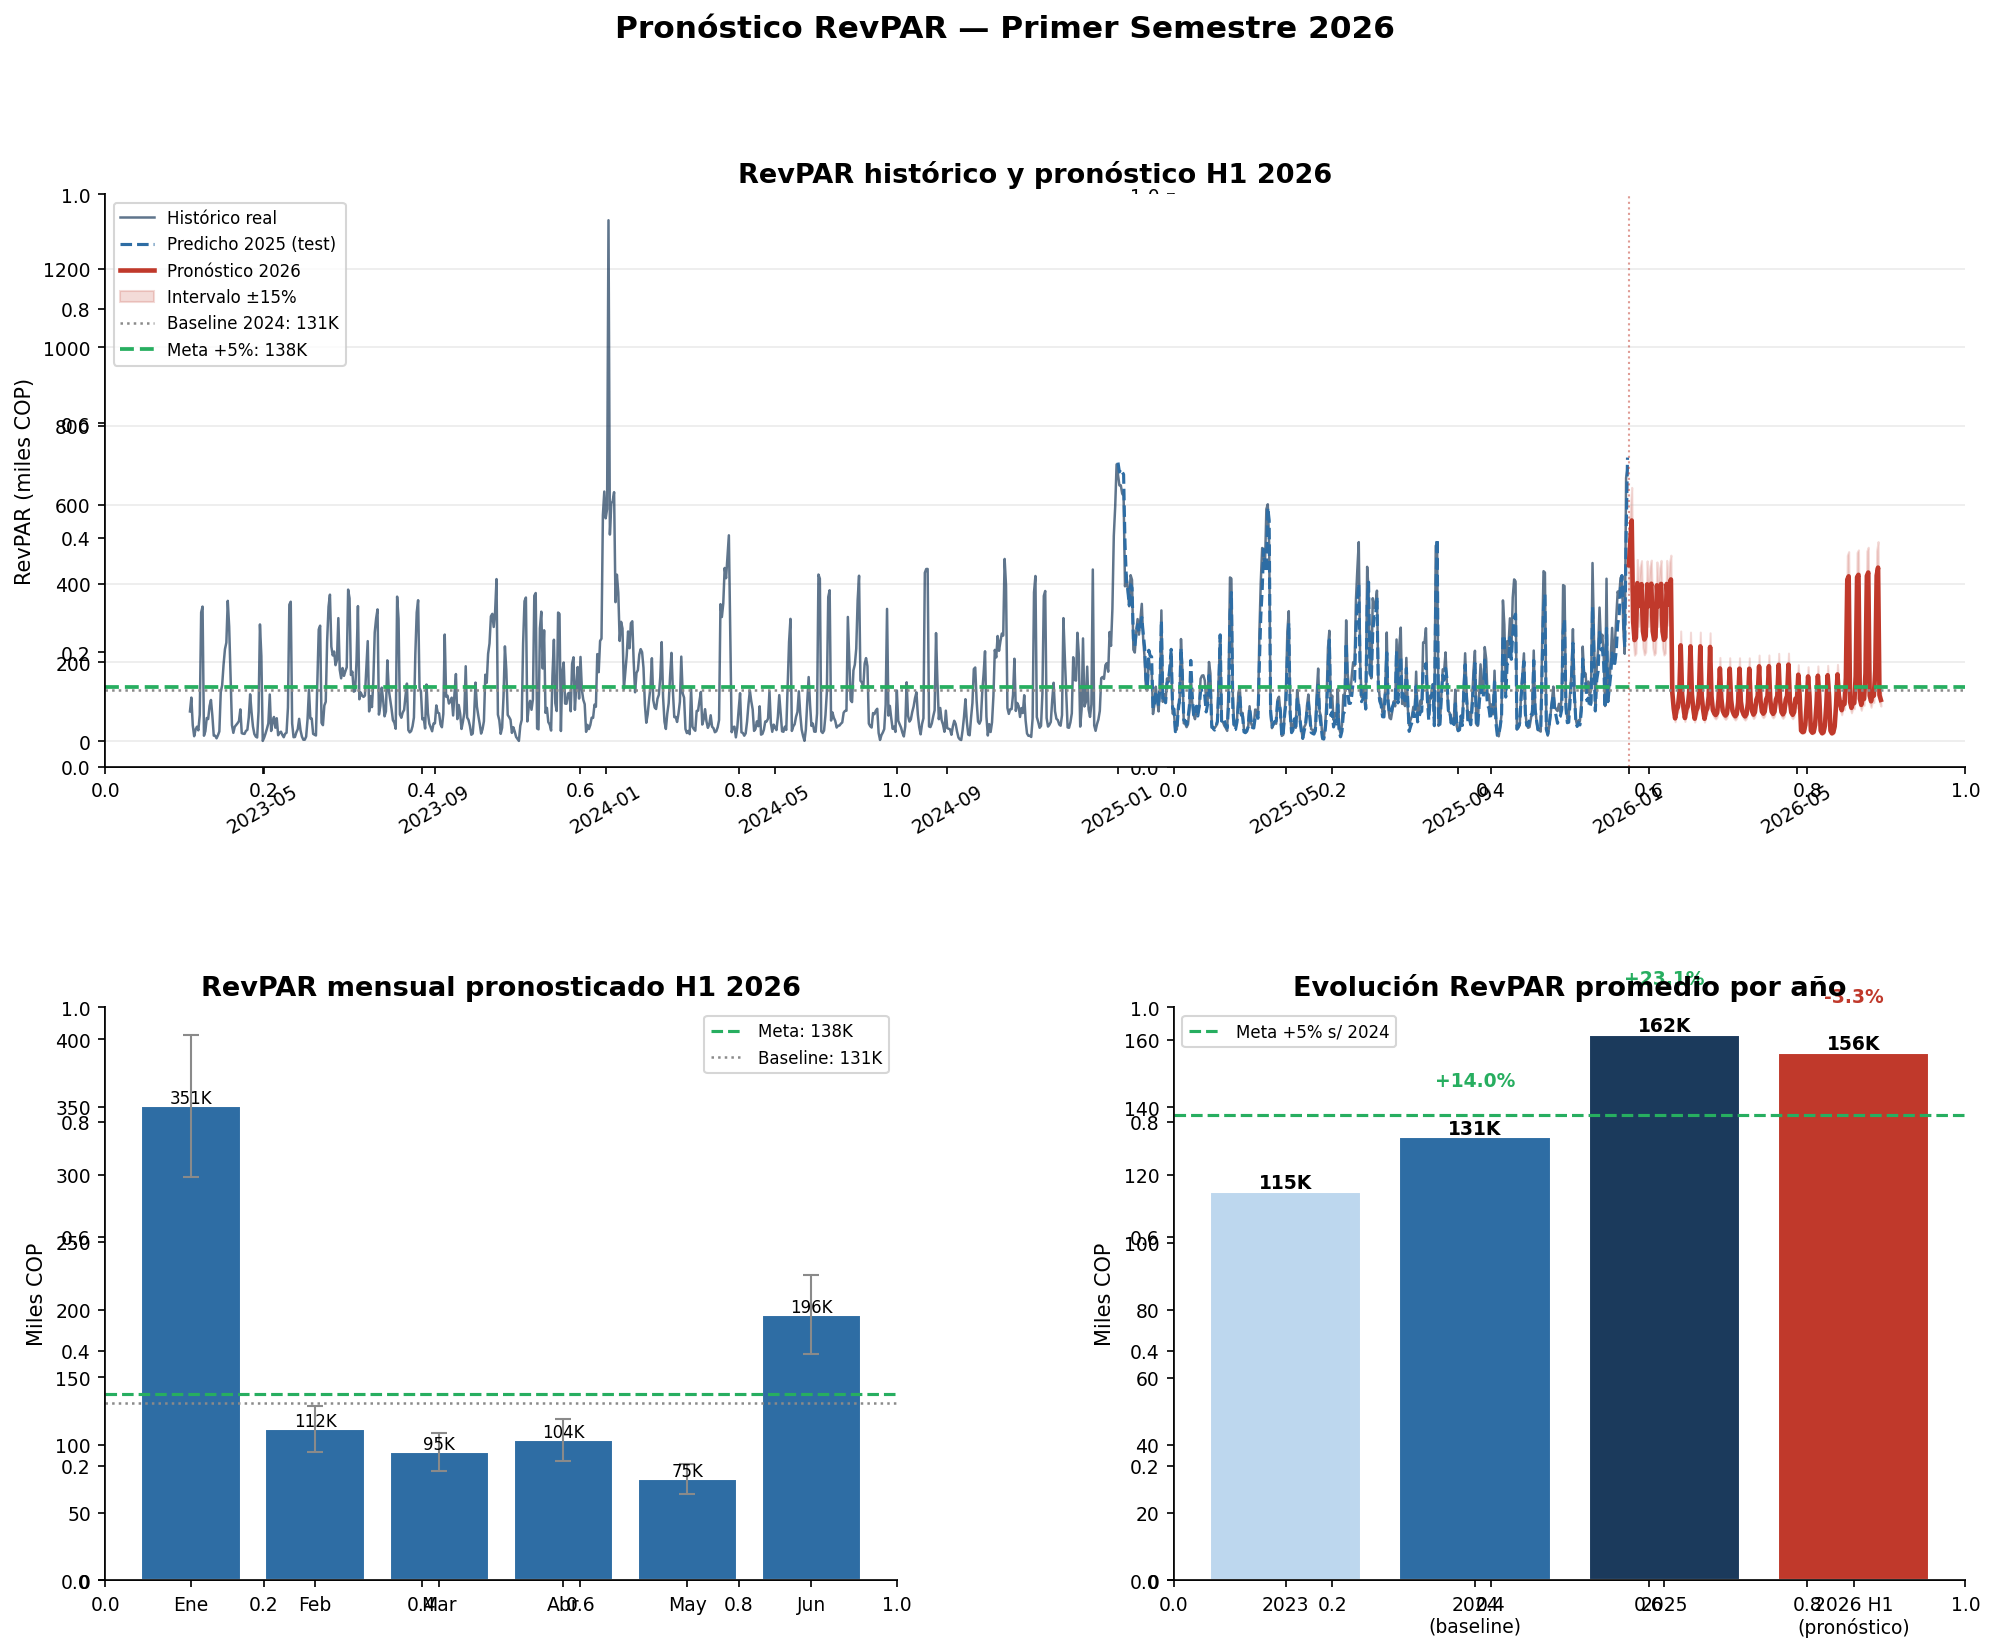

In [ ]:
from IPython.display import Image
Image('06_pronostico_2026.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 8. SIMULACIÓN DEL OBJETIVO (+5%)
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  8. SIMULACIÓN DEL OBJETIVO")
print("═"*62)

# Escenarios de pricing: subir ADR en X% y ver impacto en RevPAR
# RevPAR = ADR × Ocupación → si ADR sube 5% y ocupación se mantiene → RevPAR +5%
# Si hay elasticidad negativa (subir precio baja ocupación), el efecto real es menor

escenarios = {
    "Base (sin cambios)":    {"delta_adr": 0.00, "delta_occ": 0.000},
    "Pricing +3%":           {"delta_adr": 0.03, "delta_occ":-0.010},
    "Pricing +5%":           {"delta_adr": 0.05, "delta_occ":-0.015},
    "Pricing +8%":           {"delta_adr": 0.08, "delta_occ":-0.025},
    "Ocupación +5pp":        {"delta_adr": 0.00, "delta_occ": 0.050},
    "Combinado (+3% +3pp)":  {"delta_adr": 0.03, "delta_occ": 0.030},
}

sim_results = {}
for nombre, params in escenarios.items():
    new_adr = df[df["año"] == 2024]["adr"].mean() * (1 + params["delta_adr"])
    new_occ = min(df[df["año"] == 2024]["ocupacion"].mean() + params["delta_occ"], 1.0)
    new_revpar = new_adr * new_occ
    crec = (new_revpar / revpar_2024 - 1) * 100
    sim_results[nombre] = {
        "ADR": new_adr, "Ocupación": new_occ,
        "RevPAR": new_revpar, "Crecimiento": crec,
        "Cumple": new_revpar >= meta_revpar,
    }
    print(f"  {nombre:<28} RevPAR={new_revpar/1e3:,.0f}K  Crec={crec:.1f}%  {'✓' if new_revpar>=meta_revpar else '✗'}")

# ── Figura simulación ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Simulación de Estrategias para Alcanzar Objetivo +5% RevPAR", fontsize=14, fontweight="bold")
plt.subplots_adjust(wspace=0.38)

escen_names  = list(sim_results.keys())
revpar_sim   = [sim_results[n]["RevPAR"] / 1e3 for n in escen_names]
crec_sim     = [sim_results[n]["Crecimiento"] for n in escen_names]
cumple_sim   = [sim_results[n]["Cumple"] for n in escen_names]
colors_sim   = [VERDE if c else ROJO for c in cumple_sim]
colors_sim[0] = GRIS  # base siempre gris

# ── 8a. RevPAR por escenario ──────────────────────────────────────
ax = axes[0]
bars = ax.barh(escen_names, revpar_sim, color=colors_sim, edgecolor="white")
ax.axvline(meta_revpar / 1e3, color=DORADO, linestyle="--", linewidth=2,
           label=f"Meta +5%: {meta_revpar/1e3:,.0f}K")
ax.axvline(revpar_2024 / 1e3, color=GRIS, linestyle=":", linewidth=1.5,
           label=f"Baseline: {revpar_2024/1e3:,.0f}K")
ax.set_title("RevPAR simulado por escenario")
ax.set_xlabel("Miles COP")
ax.legend(fontsize=8)
for b, v, c in zip(bars, revpar_sim, cumple_sim):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2,
            f"{v:.0f}K {'✓' if c else '✗'}", va="center", fontsize=8,
            color=VERDE if c else ROJO)

# ── 8b. Crecimiento % por escenario ──────────────────────────────
ax = axes[1]
bars2 = ax.barh(escen_names, crec_sim, color=colors_sim, edgecolor="white")
ax.axvline(5.0, color=DORADO, linestyle="--", linewidth=2, label="Meta +5%")
ax.axvline(0.0, color=GRIS, linestyle=":", linewidth=1.2)
ax.set_title("Crecimiento RevPAR vs. baseline 2024")
ax.set_xlabel("% crecimiento")
ax.legend(fontsize=8)
for b, v in zip(bars2, crec_sim):
    ax.text(max(v, 0) + 0.05, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%", va="center", fontsize=8)

# ── 8c. Tabla de escenarios ───────────────────────────────────────
ax = axes[2]
ax.axis("off")
tabla_data = [["Escenario", "ADR (K)", "Ocup.", "RevPAR (K)", "Crec.", "Meta"]]
for n in escen_names:
    r = sim_results[n]
    tabla_data.append([
        n.split("(")[0].strip(),
        f"{r['ADR']/1e3:,.0f}",
        f"{r['Ocupación']:.1%}",
        f"{r['RevPAR']/1e3:,.0f}",
        f"{r['Crecimiento']:.1f}%",
        "✓" if r["Cumple"] else "✗",
    ])
t = ax.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
             loc="center", cellLoc="center")
t.auto_set_font_size(False)
t.set_fontsize(8)
t.scale(1, 1.55)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor(AZUL)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 1:
        cell.set_facecolor("#F2F2F2")
    cell.set_edgecolor("white")
    if c == 5 and r > 0:
        txt = cell.get_text().get_text()
        cell.set_facecolor(GREEN_BG := "#E2F4E4" if txt == "✓" else "#FCEBEB")
        cell.set_text_props(color="#0B5E14" if txt == "✓" else ROJO)
ax.set_title("Resumen de escenarios", pad=12)

plt.savefig("07_simulacion_objetivo.png")
plt.close()
print("  ✓ 07_simulacion_objetivo.png")



══════════════════════════════════════════════════════════════
  8. SIMULACIÓN DEL OBJETIVO
══════════════════════════════════════════════════════════════
  Base (sin cambios)           RevPAR=111K  Crec=-15.3%  ✗
  Pricing +3%                  RevPAR=111K  Crec=-15.1%  ✗
  Pricing +5%                  RevPAR=112K  Crec=-14.7%  ✗
  Pricing +8%                  RevPAR=112K  Crec=-14.7%  ✗
  Ocupación +5pp               RevPAR=126K  Crec=-3.9%  ✗
  Combinado (+3% +3pp)         RevPAR=124K  Crec=-5.7%  ✗
  ✓ 07_simulacion_objetivo.png


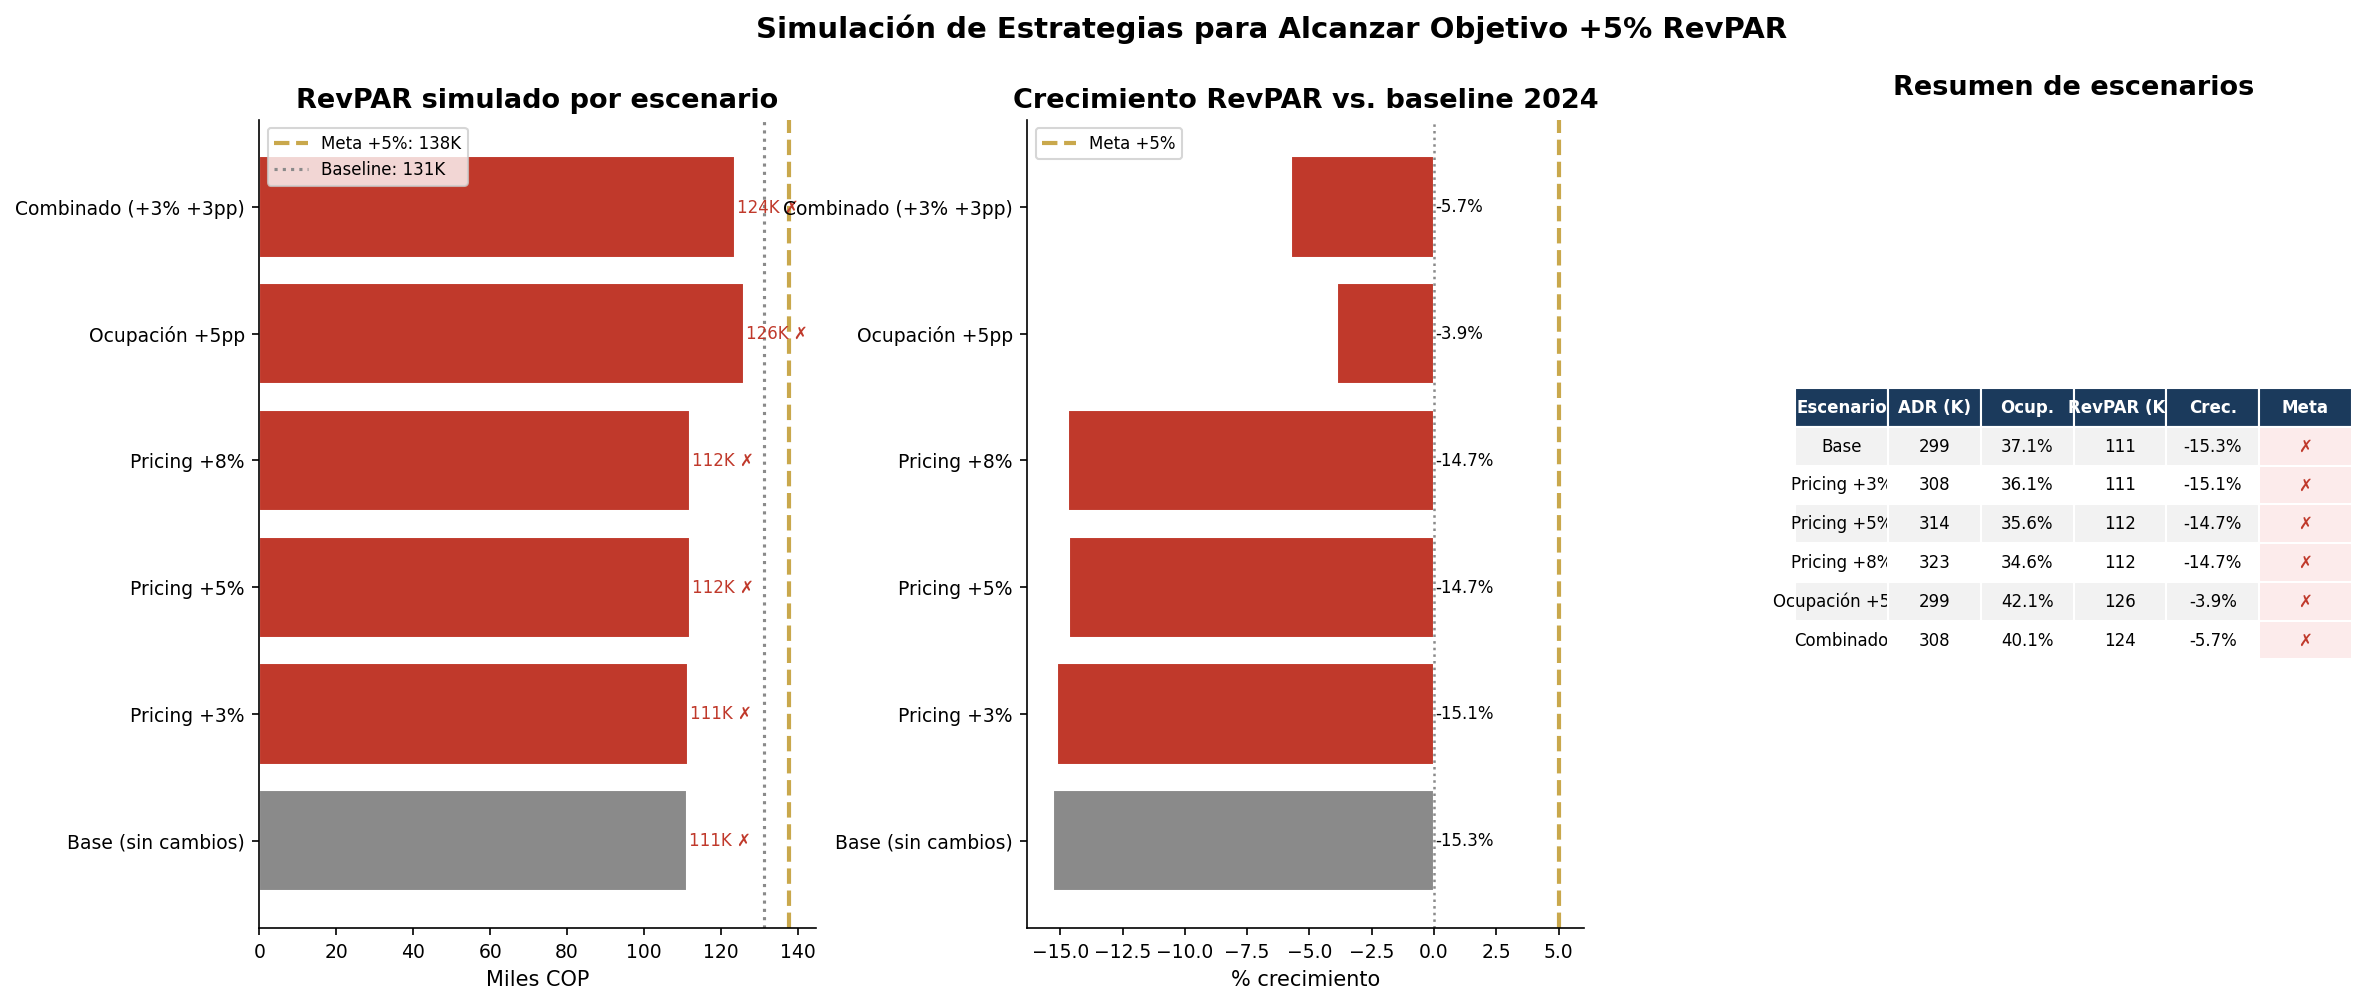

In [ ]:
from IPython.display import Image
Image('07_simulacion_objetivo.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 9. EXCEL DE RESULTADOS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  9. GENERANDO EXCEL")
print("═"*62)

DARK_BLUE  = "1B3A5C"
MID_BLUE   = "2E6DA4"
PALE_BLUE  = "DEEAF6"
WHITE_XL   = "FFFFFF"
GRAY_LIGHT = "F2F2F2"
TEXT_DARK  = "1A1A1A"
GREEN_BG   = "E2F4E4"
GREEN_FG   = "0B5E14"
RED_BG     = "FCEBEB"
RED_FG     = "A32D2D"

def thin_brd():
    s = Side(style="thin", color="CCCCCC")
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, row, col, text, bg=DARK_BLUE, fg=WHITE_XL, sz=10, bold=True):
    c = ws.cell(row=row, column=col, value=text)
    c.font = Font(name="Arial", bold=bold, color=fg, size=sz)
    c.fill = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = thin_brd()
    return c

def cel(ws, row, col, value, bg=WHITE_XL, fg=TEXT_DARK, bold=False, fmt=None, al="left"):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(name="Arial", bold=bold, color=fg, size=9)
    c.fill = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal=al, vertical="center", wrap_text=True)
    if fmt:
        c.number_format = fmt
    c.border = thin_brd()
    return c

wb = openpyxl.Workbook()

# ── Hoja 1: Resumen ejecutivo ─────────────────────────────────────
ws1 = wb.active
ws1.title = "Resumen Ejecutivo"
ws1.sheet_view.showGridLines = False
for col, w in [("A",30),("B",16),("C",16),("D",16),("E",16),("F",18)]:
    ws1.column_dimensions[col].width = w

ws1.row_dimensions[1].height = 44
ws1.merge_cells("A1:F1")
c = ws1["A1"]
c.value = "MODELO DE PRONÓSTICO RevPAR — HOTEL"
c.font = Font(name="Arial", bold=True, color=WHITE_XL, size=14)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")

ws1.row_dimensions[2].height = 20
ws1.merge_cells("A2:F2")
c = ws1["A2"]
c.value = (f"Objetivo: RevPAR +5% en 6 meses | Modelo: {best_model_name} | "
           f"MAPE={met_res['MAPE']*100:.1f}% | R²={met_res['R2']:.3f}")
c.font = Font(name="Arial", color=DARK_BLUE, size=9, italic=True)
c.fill = PatternFill("solid", fgColor=PALE_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")

ws1.row_dimensions[3].height = 8

kpi_data = [
    ("A","RevPAR\nbaseline 2024", f"{revpar_2024/1e3:,.0f}K"),
    ("B","RevPAR\nreal 2025",     f"{revpar_2025/1e3:,.0f}K"),
    ("C","Meta RevPAR\n(+5%)",    f"{meta_revpar/1e3:,.0f}K"),
    ("D","Pronóstico\nH1 2026",   f"{revpar_2026_h1_pred/1e3:,.0f}K"),
    ("E","Crecimiento\nvs. 2024", f"{crec_vs_baseline:.1f}%"),
    ("F","Cumple\nobjetivo",      "SÍ ✓" if cumple_objetivo else "NO ✗"),
]
for col_l, lbl, val in kpi_data:
    c1 = ws1[f"{col_l}4"]
    c1.value = lbl
    c1.font = Font(name="Arial", bold=True, color=WHITE_XL, size=9)
    c1.fill = PatternFill("solid", fgColor=MID_BLUE)
    c1.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c1.border = thin_brd()
    ws1.row_dimensions[4].height = 30
    c2 = ws1[f"{col_l}5"]
    c2.value = val
    c2.font = Font(name="Arial", bold=True, color=DARK_BLUE, size=16)
    c2.fill = PatternFill("solid", fgColor=PALE_BLUE)
    c2.alignment = Alignment(horizontal="center", vertical="center")
    c2.border = thin_brd()
    ws1.row_dimensions[5].height = 34

# Métricas de modelos
ws1.row_dimensions[6].height = 8
ws1.merge_cells("A7:F7")
c = ws1["A7"]
c.value = "COMPARACIÓN DE MODELOS"
c.font = Font(name="Arial", bold=True, color=WHITE_XL, size=11)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[7].height = 24

for j, h in enumerate(["Modelo","MAPE (%)","R²","MAE (COP)","RMSE (COP)","Seleccionado"], 1):
    hdr(ws1, 8, j, h)
ws1.row_dimensions[8].height = 24

for i, (name, res) in enumerate(resultados.items()):
    r = 9 + i
    ws1.row_dimensions[r].height = 22
    is_best = name == best_model_name
    alt = GRAY_LIGHT if i % 2 else WHITE_XL
    bg  = GREEN_BG if is_best else alt
    row_data = [
        (name,                   bg, DARK_BLUE if is_best else TEXT_DARK, is_best, None,   "left"),
        (res["MAPE"]*100,        bg, TEXT_DARK, False, "0.00", "center"),
        (res["R2"],              bg, TEXT_DARK, False, "0.000","center"),
        (res["MAE"],             bg, TEXT_DARK, False, "#,##0","right"),
        (res["RMSE"],            bg, TEXT_DARK, False, "#,##0","right"),
        ("✓ Seleccionado" if is_best else "—", GREEN_BG if is_best else alt,
         GREEN_FG if is_best else TEXT_DARK, is_best, None, "center"),
    ]
    for j, (v, b, fg, bold, fmt, al) in enumerate(row_data, 1):
        cel(ws1, r, j, v, bg=b, fg=fg, bold=bold, fmt=fmt, al=al)

# ── Hoja 2: Pronóstico H1 2026 ────────────────────────────────────
ws2 = wb.create_sheet("Pronóstico H1 2026")
ws2.sheet_view.showGridLines = False
for col, w in [("A",14),("B",12),("C",10),("D",12),("E",12),("F",18),("G",18),("H",18),("I",14)]:
    ws2.column_dimensions[col].width = w

ws2.merge_cells("A1:I1")
c = ws2["A1"]
c.value = "PRONÓSTICO DIARIO RevPAR — PRIMER SEMESTRE 2026"
c.font = Font(name="Arial", bold=True, color=WHITE_XL, size=13)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws2.row_dimensions[1].height = 32

for j, h in enumerate(["Fecha","Día Sem.","Mes","Fin Semana","Temporada",
                        "RevPAR Pronóstico (COP)","IC Inferior (COP)","IC Superior (COP)",
                        "Cumple Meta"], 1):
    hdr(ws2, 2, j, h)
ws2.row_dimensions[2].height = 28

dia_semana_lbl = {0:"Lun",1:"Mar",2:"Mié",3:"Jue",4:"Vie",5:"Sáb",6:"Dom"}
temp_lbl = {2:"Alta", 1:"Media", 0:"Baja"}

for idx, row in future.iterrows():
    r = idx + 3 - future.index[0]
    ws2.row_dimensions[r].height = 18
    cumple = row["revpar_pred"] >= meta_revpar
    alt = GRAY_LIGHT if idx % 2 else WHITE_XL
    data_row = [
        (row["fecha_noche"].date(), alt, TEXT_DARK, False, "DD/MM/YYYY", "center"),
        (dia_semana_lbl[row["dow"]], alt, TEXT_DARK, False, None, "center"),
        (mes_lbl[row["mes"]-1],     alt, TEXT_DARK, False, None, "center"),
        ("Sí" if row["fin_semana"] else "No", alt, TEXT_DARK, False, None, "center"),
        (row["temporada"],          alt, TEXT_DARK, False, None, "center"),
        (row["revpar_pred"],        alt, TEXT_DARK, True,  "#,##0", "right"),
        (row["revpar_lo"],          alt, TEXT_DARK, False, "#,##0", "right"),
        (row["revpar_hi"],          alt, TEXT_DARK, False, "#,##0", "right"),
        ("✓" if cumple else "✗",   GREEN_BG if cumple else RED_BG,
         GREEN_FG if cumple else RED_FG, True, None, "center"),
    ]
    for j, (v, bg, fg, bold, fmt, al) in enumerate(data_row, 1):
        cel(ws2, r, j, v, bg=bg, fg=fg, bold=bold, fmt=fmt, al=al)

ws2.auto_filter.ref = "A2:I2"
ws2.freeze_panes = "A3"

# ── Hoja 3: Escenarios de pricing ─────────────────────────────────
ws3 = wb.create_sheet("Escenarios de Pricing")
ws3.sheet_view.showGridLines = False
for col, w in [("A",30),("B",16),("C",14),("D",18),("E",14),("F",14)]:
    ws3.column_dimensions[col].width = w

ws3.merge_cells("A1:F1")
c = ws3["A1"]
c.value = "SIMULACIÓN DE ESCENARIOS PARA ALCANZAR OBJETIVO +5% RevPAR"
c.font = Font(name="Arial", bold=True, color=WHITE_XL, size=12)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws3.row_dimensions[1].height = 32

for j, h in enumerate(["Escenario","ADR Simulado (COP)","Ocupación","RevPAR Simulado (COP)",
                        "Crecimiento vs. 2024","Cumple Objetivo"], 1):
    hdr(ws3, 2, j, h)
ws3.row_dimensions[2].height = 26

for i, (name, res) in enumerate(sim_results.items()):
    r = 3 + i
    ws3.row_dimensions[r].height = 24
    cumple = res["Cumple"]
    alt = GRAY_LIGHT if i % 2 else WHITE_XL
    data_row = [
        (name,              alt, TEXT_DARK, False, None,    "left"),
        (res["ADR"],        alt, TEXT_DARK, False, "#,##0", "right"),
        (res["Ocupación"],  alt, TEXT_DARK, False, "0.0%",  "center"),
        (res["RevPAR"],     alt, TEXT_DARK, True,  "#,##0", "right"),
        (res["Crecimiento"]/100, alt, TEXT_DARK, False, "0.0%", "center"),
        ("✓ SÍ" if cumple else "✗ NO",
         GREEN_BG if cumple else RED_BG,
         GREEN_FG if cumple else RED_FG, True, None, "center"),
    ]
    for j, (v, bg, fg, bold, fmt, al) in enumerate(data_row, 1):
        cel(ws3, r, j, v, bg=bg, fg=fg, bold=bold, fmt=fmt, al=al)

# ── Hoja 4: Datos históricos + RevPAR ────────────────────────────
ws4 = wb.create_sheet("Histórico RevPAR")
ws4.sheet_view.showGridLines = False
hist_cols = ["fecha_noche","año","mes","dow","fin_semana","temporada",
             "ocupacion","adr","revpar","ingresos","cuartos_ocupados",
             "precipitacion_mm","sol_horas","PIB_diario_MMM"]
hist_lbls = ["Fecha","Año","Mes","Día Sem.","Fin Semana","Temporada",
             "Ocupación","ADR (COP)","RevPAR (COP)","Ingresos (COP)",
             "Cuartos Ocup.","Precipitación (mm)","Sol (horas)","PIB diario (MM COP)"]
hist_w   = [13,8,6,9,11,10,10,14,14,18,13,14,12,16]

for j, (lbl, w) in enumerate(zip(hist_lbls, hist_w), 1):
    ws4.column_dimensions[get_column_letter(j)].width = w
    hdr(ws4, 1, j, lbl)
ws4.row_dimensions[1].height = 28

df_export = df[hist_cols].copy()
for idx in range(len(df_export)):
    row = df_export.iloc[idx]
    r = idx + 2
    alt = GRAY_LIGHT if idx % 2 else WHITE_XL
    for j, col in enumerate(hist_cols, 1):
        val = row[col]
        c = ws4.cell(row=r, column=j, value=val)
        c.font = Font(name="Arial", size=9, color=TEXT_DARK)
        c.fill = PatternFill("solid", fgColor=alt)
        c.alignment = Alignment(horizontal="center", vertical="center")
        if col in ["adr","revpar","ingresos"]:      c.number_format = "#,##0"
        elif col in ["ocupacion"]:                   c.number_format = "0.0%"
        elif col in ["precipitacion_mm","sol_horas","PIB_diario_MMM"]: c.number_format = "0.0"
        c.border = thin_brd()

ws4.auto_filter.ref = f"A1:{get_column_letter(len(hist_cols))}1"
ws4.freeze_panes = "A2"

OUTPUT_XL = "Pronostico_RevPAR_Hotel.xlsx"
wb.save(OUTPUT_XL)
print(f"  ✓ {OUTPUT_XL}")



══════════════════════════════════════════════════════════════
  9. GENERANDO EXCEL
══════════════════════════════════════════════════════════════
  ✓ Pronostico_RevPAR_Hotel.xlsx


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 10. RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  RESUMEN FINAL")
print("═"*62)
print(f"  Modelo seleccionado  : {best_model_name}")
print(f"  MAPE (test 2025)     : {met_res['MAPE']*100:.2f}%")
print(f"  R² (test 2025)       : {met_res['R2']:.4f}")
print(f"  CV MAPE (5-fold TS)  : {np.mean(cv_mapes)*100:.2f}% ± {np.std(cv_mapes)*100:.2f}%")
print(f"  RevPAR baseline 2024 : {revpar_2024:>12,.0f} COP")
print(f"  RevPAR pronóstico H1 : {revpar_2026_h1_pred:>12,.0f} COP")
print(f"  Crecimiento estimado : {crec_vs_baseline:>11.1f} %")
print(f"  Objetivo +5% cumplido: {'SÍ ✓' if cumple_objetivo else 'NO — requiere estrategia de pricing'}")
print("─"*62)
print("  Archivos generados:")
for f in ["01_eda_revpar.png","02_estacionalidad.png","03_preparacion_features.png",
          "04_comparacion_modelos.png","05_diagnostico_modelo.png",
          "06_pronostico_2026.png","07_simulacion_objetivo.png",
          "Pronostico_RevPAR_Hotel.xlsx"]:
    print(f"    · {f}")
print("═"*62 + "\n")



══════════════════════════════════════════════════════════════
  RESUMEN FINAL
══════════════════════════════════════════════════════════════
  Modelo seleccionado  : Random Forest
  MAPE (test 2025)     : 15.55%
  R² (test 2025)       : 0.9353
  CV MAPE (5-fold TS)  : 25.38% ± 9.92%
  RevPAR baseline 2024 :      131,204 COP
  RevPAR pronóstico H1 :      156,188 COP
  Crecimiento estimado :        19.0 %
  Objetivo +5% cumplido: SÍ ✓
──────────────────────────────────────────────────────────────
  Archivos generados:
    · 01_eda_revpar.png
    · 02_estacionalidad.png
    · 03_preparacion_features.png
    · 04_comparacion_modelos.png
    · 05_diagnostico_modelo.png
    · 06_pronostico_2026.png
    · 07_simulacion_objetivo.png
    · Pronostico_RevPAR_Hotel.xlsx
══════════════════════════════════════════════════════════════

